### Libraries + Keys

In [1]:
import os
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf
import yh_finance as yhf
import mplfinance as mpf
import requests
import json
import ipywidgets as widgets
import matplotlib.ticker as mticker
import smtplib
from datetime import datetime, timedelta, date, time
from typing import Iterable, Optional, Any
from IPython.display import display, Markdown, HTML
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.application import MIMEApplication
from zoneinfo import ZoneInfo
import nbformat
from pathlib import Path
from nbconvert.exporters import HTMLExporter
from nbconvert.preprocessors import TagRemovePreprocessor
from email.utils import formatdate
from IPython.display import HTML, display

NEWS_API_KEY = '' # For News API. 1000 requests/day, 100 results/query
YHF_API_KEY = ''
BEN_API_KEY = ''
FMP_API_KEY = ''
GMAIL_APP_PASSWORD = '' # For sending out emails
currentTimezone = "America/Toronto"

start_ts = datetime.now(ZoneInfo(currentTimezone))

MAX_TICKERS          = 50
PRICE_OF_INTEREST    = 30 # No nos interesan acciones > $30
LOWEST_PRICE         = 7  # No nos interesan acciones < $7

DAILY_VOLUME         = 1000000  # Daily Trading Volume
PRICE_CHANGE         = 0.5     # Cambio en precio +- > 0.5 


DATES_DAYS_INTEREST  = 30    # For important dates for a ticker. How many days to scan in advance

NEWS_DAYS_INTEREST   = 3      # When picking dates of interest how many days to look at
NEWS_PAGE_SIZE       = 5      # Num of pages of news to download
NUM_NEWS             = 5      # Limit hoe many news articles per ticker

# Plotting Options
DEFAULT_TITLE_PAD    = 18      # axes title distance (if suptitle is not used)
DEFAULT_TITLE_Y      = 0.995   # suptitle vertical position (0..1, higher = further from data)
DEFAULT_TOP_MARGIN   = 0.88   # subplots area top; lower value = more headroom for title

# OUTPUT PATH
tz = ZoneInfo(currentTimezone)
today_str = datetime.now(tz).date().isoformat()

NOTEBOOK_PATH = "/home/runner/FinanceNotebook/FinMarketsNotebook.ipynb"
HTML_OUT_PATH = f"/home/runner/FinanceNotebook/Outputs/Market_{today_str}.html"

# # Windows Machine
# NOTEBOOK_PATH = "C:\\Projects\\FinMarketsNotebook.ipynb"
# HTML_OUT_PATH = f"C:\\Projects\\OutputsFolder\\Market_{today_str}.html"

TARGET_EMAIL = "hectorsalermo@yahoo.ca"

# Enabling/Disabling 
getNews = True
getPlots = True
exportHtml = True 
sendEmail = True



### Functions

#### Main Functionality

In [2]:
def get_stock_data(symbols: list, start_date: str = (datetime.now() - timedelta(days=5)).strftime('%Y-%m-%d'),  end_date: str = datetime.now().strftime('%Y-%m-%d'),  interval: str = '1d') -> pd.DataFrame:
    """
    Downloads stock data for a given symbol and date range.

    Parameters:
    - symbol (str): The stock symbol to download (default 'JBLU').
    - start_date (str): The start date in 'YYYY-MM-DD' format (default '2025-01-02').
    - end_date (str): The end date in 'YYYY-MM-DD' format (default '2025-01-03').
    - interval (str): The data interval. Options include '1m', '5m', '15m', '1h', '1d', etc. (default '1m').

    Returns:
    - pd.DataFrame: A pandas DataFrame containing the stock data for the specified period.
    """
    # Download the stock data
    data = yf.download(symbols, start=start_date, end=end_date, interval=interval)
    
    # Return the downloaded data as a DataFrame
    return data

def get_company_name(ticker):
    # Use the Yahoo Finance API to get the company name
    try:
        stock = yf.Ticker(ticker)
        company_name = stock.info.get('longName', 'N/A')  # Get the full company name
        return company_name
    except Exception as e:
        print(f"Error getting company name for {ticker}: {e}")
        return 'N/A'

def search_news_to_df(ticker, API_KEY, pageSize):
    url = 'https://newsapi.org/v2/everything'
    params = {
        'q': ticker,              # The ticker symbol (e.g., 'AAPL')
        'apiKey': API_KEY,        # Your API key
        'language': 'en',         # Filter news in English
        'sortBy': 'publishedAt',  # Sort by the most recent news
        'pageSize': pageSize             # Number of articles to return
    }
    
    # Send the request to the NewsAPI endpoint
    response = requests.get(url, params=params)
    
    # Check if the response was successful
    if response.status_code == 200:
        data = response.json()
        
        # Check if 'articles' is present in the response
        if 'articles' in data:
            articles = data['articles']
            # Create a list to hold the article data
            article_data = []
            
            for article in articles:
                title = article.get('title', 'N/A')
                url = article.get('url', 'N/A')
                author = article.get('author', 'N/A')
                source = article.get('source', {}).get('name', 'N/A')
                published_at = article.get('publishedAt', 'N/A')
                last_modified_at = article.get('lastModifiedAt', 'N/A')  # NewsAPI doesn't provide 'lastModifiedAt'
                
                # Get the company name from the ticker using Yahoo Finance
                company_name = get_company_name(ticker)
                
                # Append the article data along with the ticker and company name to the list
                article_data.append([ticker, company_name, title, url, author, source, published_at, last_modified_at])
            
            # Convert the list to a DataFrame
            df = pd.DataFrame(article_data, columns=[
                'Ticker', 'Company Name', 'Title', 'Link', 'Author', 'Source', 'Published At', 'Last Modified At'])
            df = df.sort_values(by=['Published At'], ascending=False)
            return df
        else:
            print(f"No articles found for ticker {ticker}.")
            return pd.DataFrame()  # Return an empty DataFrame if no articles found
    else:
        print(f"Error: {response.status_code}, {response.text}")
        return pd.DataFrame()  # Return an empty DataFrame in case of an error

def send_html_email(sender_email, receiver_email, subject, html_body, app_password):
    """
    Function to send an email with an HTML body using Gmail with an app password.
    
    Args:
    - sender_email (str): The sender's email address (Gmail).
    - receiver_email (str): The recipient's email address.
    - subject (str): The subject of the email.
    - html_body (str): The HTML content to send in the email body.
    - app_password (str): The Gmail app password for authentication.
    
    Returns:
    - None
    """
    # Create message
    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = receiver_email
    msg['Subject'] = subject
    msg.attach(MIMEText(html_body, 'html'))  # Attach HTML content to the email body

    try:
        # Establish connection to Gmail's SMTP server
        with smtplib.SMTP_SSL('smtp.gmail.com', 465) as server:
            server.login(sender_email, app_password)  # Login with the sender's email and app password
            server.sendmail(sender_email, receiver_email, msg.as_string())  # Send the email
            print("Email sent successfully!")

    except Exception as e:
        print(f"Error: {e}")

def send_html_email_with_attachment(
    sender_email: str,
    receiver_email: str | list[str],
    subject: str,
    html_path: str,
    app_password: str,
    summary_html: str | None = None
):
    """
    Sends an email with a small inline (HTML) summary and attaches the full HTML report.

    - sender_email: Gmail address of the sender
    - receiver_email: recipient email or list of emails
    - subject: email subject
    - html_path: path to the .html file to attach
    - app_password: Gmail App Password (requires 2FA on the account)
    - summary_html: optional short HTML to show inline in the email body
    """
    html_file = Path(html_path)
    if not html_file.exists():
        raise FileNotFoundError(f"HTML file not found: {html_file}")

    # Root message (mixed = attachments allowed)
    msg = MIMEMultipart("mixed")
    msg["From"] = sender_email
    # Accept str or list for recipients
    if isinstance(receiver_email, list):
        msg["To"] = ", ".join(receiver_email)
    else:
        msg["To"] = receiver_email
    msg["Subject"] = subject
    msg["Date"] = formatdate(localtime=True)

    # --- Lightweight inline body (alternative = plain + html) ---
    alt = MIMEMultipart("alternative")
    alt.attach(MIMEText("Full market report attached.", "plain", _charset="utf-8"))
    if summary_html is None:
        summary_html = f"""
<html>
    <head></head>
    <body>
    <h2>Tickers of Interest for Today: {today_str} </h2>
    <p>Completion time for the playbook execution: {timestamp}</p>
    </body>
</html>
"""
    alt.attach(MIMEText(summary_html, "html", _charset="utf-8"))
    msg.attach(alt)

    # --- Attach the .html report ---
    data = html_file.read_bytes()
    part = MIMEApplication(data, _subtype="html")
    part.add_header("Content-Disposition", "attachment", filename=html_file.name)
    msg.attach(part)

    # Optional: quick size note (remember base64 adds ~33%)
    size_mb = os.path.getsize(html_file) / (1024 * 1024)
    approx_encoded_mb = size_mb * 1.37  # rougher but safer upper bound than 1.33
    print(f"Attachment size: {size_mb:.2f} MB (approx {approx_encoded_mb:.2f} MB encoded).")

    # --- Send ---
    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
        server.login(sender_email, app_password)
        server.send_message(msg)
        print("Email sent successfully!")

def fetch_gainers_losers_fmp(api_key: str):
    """
    Fetch top gainers and losers using the updated FMP v4 API endpoints.

    Args:
        api_key (str): FMP API key.

    Returns:
        tuple: (gainers_df, losers_df) as pandas DataFrames.
    """
    endpoints = {
        "gainers": f"https://financialmodelingprep.com/stable/biggest-gainers?apikey={api_key}",
        "losers":  f"https://financialmodelingprep.com/stable/biggest-losers?apikey={api_key}",
        "top_traded": f"https://financialmodelingprep.com/stable/most-actives?apikey={api_key}"
    }

    def get_data(url):
        try:
            response = requests.get(url)
            response.raise_for_status()
            return response.json()
        except requests.exceptions.RequestException as e:
            print(f"API request failed: {e}")
            return []

    gainers_df     = pd.DataFrame(get_data(endpoints["gainers"]))
    losers_df      = pd.DataFrame(get_data(endpoints["losers"]))
    top_traded_df  = pd.DataFrame(get_data(endpoints["top_traded"]))

   
    return gainers_df, losers_df, top_traded_df

def get_history_table(symbol):
    """
    Returns a numeric DataFrame with:
      • last 7 trading days
      • row on/before ~1 month ago
      • row on/before ~6 months ago

    Columns: label, datetime, Open, High, Low, Close, Volume
    """
    if isinstance(symbol, str):
        tick = yf.Ticker(symbol)

    # ~7 months to safely cover 6M lookback
    hist = tick.history(period="7mo", interval="1d", actions=False)  # OHLCV only
    if hist.empty:
        raise ValueError("No history returned. Try a different ticker or wider period.")

    # last 7 trading days
    last7 = hist.tail(7).copy()
    last7["label"] = "last_7d"

    # lookbacks (nearest trading day ON or BEFORE those dates)
    anchor = hist.index.max()
    d1m = anchor - pd.DateOffset(months=1)
    d6m = anchor - pd.DateOffset(months=6)

    one_month_row = hist.loc[:d1m].tail(1).copy(); one_month_row["label"] = "1M_ago"
    six_month_row = hist.loc[:d6m].tail(1).copy(); six_month_row["label"] = "6M_ago"

    # combine, order, and keep only the columns we care about
    table = (
        pd.concat([last7, one_month_row, six_month_row], axis=0)
          .reset_index()
          .rename(columns={"Date": "datetime"})
          .sort_values("datetime", ascending=False)
          .reset_index(drop=True)
    )

    table['symbol'] = symbol
    table['DayVar'] = (table['Close'] - table['Open']).round(3)

    return table

#### Plotting Functions

In [3]:
"""
What you can do with it

1) Choose time resolution & window

interval: "1m" | "2m" | "5m" | "15m" | "30m" | "60m" | "90m" | "1h" | "1d"
period: "1d" | "5d" | "1mo" | "3mo" | "6mo" | "1y" | "2y" | "5y" | "10y" | "ytd" | "max"  or start="YYYY-MM-DD", end="YYYY-MM-DD" (mutually exclusive with period)

# Intraday: last week, 5-minute candles
plot_candles("AAPL", interval="5m", period="7d")
# Multi-week intraday: coarser candles help avoid Yahoo downshift
plot_candles("AAPL", interval="15m", period="30d")
# Daily bars for the last 6 months
plot_candles("AAPL", interval="1d", period="6mo")
# Explicit date range (intraday)
plot_candles("AAPL", interval="5m", start="2025-10-20", end="2025-11-03")

2) Control session hours and pre/after-market
prepost=True fetches pre/after-hours (useful for indicators like VWAP).
strip_regular_only=True displays only 09:30–16:00 ET after fetching.

plot_candles("TSLA", interval="5m", period="5d", prepost=True, strip_regular_only=True)


3) Add overlays for context
mav=(10,20,50) adds moving averages (MA10/20/50 by bar count).
vwap=True overlays session-anchored VWAP (resets each calendar day).
earnings_markers=True draws a vertical line on earnings dates in view.

# Intraday with VWAP + MAs + earnings lines
plot_candles("MSFT", interval="5m", period="5d",
             prepost=True, strip_regular_only=True,
             mav=(8,21,50), vwap=True, earnings_markers=True)

             
4) Styling, legend, size, and saving

style: "yahoo", "charles", "blueskies", etc., or a custom mpf style object.
figsize=(width, height) in inches.
show_legend=True shows labels for MAs/VWAP (the function adds it post-plot).
include_volume=True/False toggles the volume panel (formatted in “M”).
savepath="chart.png" writes a high-DPI image to disk.

# Big, clean chart with legend, no volume, saved to disk
plot_candles("NVDA", interval="15m", period="10d",
             include_volume=False, show_legend=True,
             style="yahoo", figsize=(14,7), savepath="nvda_15m_10d.png")

5) Handle data quirks and rate limits
If Yahoo downshifts your requested interval (e.g., 5m → daily), the function raises:
“Requested interval '5m' likely not honored…”
Fix: shorten period (e.g., 5d), or use a coarser interval (e.g., 15m).
If you see 429s or empty returns, reuse a requests.Session() with yfinance to reduce handshakes:

import requests, yfinance as yf
sess = requests.Session()
tk = yf.Ticker("AAPL", session=sess)
# Optionally tweak the function to accept `yf_ticker=tk` to reuse the session.

6) Batch and automation patterns
Loop over tickers and save files for a daily briefing:

for t in ["AAPL","MSFT","NVDA","TSLA"]:
    plot_candles(t, interval="15m", period="5d",
                 prepost=True, strip_regular_only=True,
                 mav=(10,20,50), vwap=True,
                 show_legend=True, savepath=f"out/{t}_15m_5d.png")

Embed in reports: generate PNGs and drop them into slides/emails.
Backtesting visuals: compute your own signals (PnL, entries/exits) and add them as extra addplot series (I can extend the helper to accept extra_overlays=[Series or (Series, kwargs)] so you can label them and auto-legend).

7) Common “gotchas” and quick fixes
“No bars remain after filtering to 09:30–16:00”: your window hits weekends/holidays or only pre/after. Set strip_regular_only=False or pick a different window.
Mixed timezone index: the function normalizes timestamps to tz="America/Toronto". Change tz if you prefer another view.
Non-US markets: strip_regular_only assumes US equities hours—set it False or adjust to that market’s RTH in a custom variant.

"""

def _granularity_ok(idx: pd.DatetimeIndex, requested_interval: str, tolerance: float = 1.5) -> bool:
    """Return True if median spacing <= tolerance * requested interval (detect Yahoo downshift)."""
    if len(idx) < 3:
        return True
    to_min = {"1m":1,"2m":2,"5m":5,"15m":15,"30m":30,"60m":60,"90m":90,"1h":60,"1d":1440,"5d":7200}
    req_min = to_min.get(requested_interval)
    if req_min is None:
        return True
    s1 = pd.Series(idx[1:], index=range(len(idx)-1))
    s0 = pd.Series(idx[:-1], index=range(len(idx)-1))
    med_minutes = (s1 - s0).dt.total_seconds().median() / 60.0
    return med_minutes <= req_min * tolerance

def _format_volume_axis(ax):
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x/1_000_000:.1f}M"))

# ---------- main ----------

def plot_candles(
    ticker: str,
    *,
    interval: str = "5m",
    period: Optional[str] = "7d",
    start: Optional[str | pd.Timestamp] = None,
    end: Optional[str | pd.Timestamp] = None,
    prepost: bool = False,
    include_volume: bool = True,
    style: str | Any = "yahoo",             # string style name or mpf style object
    figsize: tuple[int, int] = (12, 6),
    mav: Iterable[int] | None = (10, 20, 50),  # will be plotted as labeled addplots
    vwap: bool = True,                       # session-anchored (by calendar day) VWAP
    strip_regular_only: bool = False,        # filter to 09:30–16:00 ET after fetching
    tz: str = "America/Toronto",
    earnings_markers: bool = True,
    show_legend: bool = True,                # we draw legend manually after plotting
    savepath: Optional[str] = None,
     # --- NEW: title spacing controls ---
    title_pad: int = DEFAULT_TITLE_PAD,
    title_y: float = DEFAULT_TITLE_Y,
    top_margin: float = DEFAULT_TOP_MARGIN,
):
    """Plot a flexible candlestick chart with MAs, VWAP, earnings vlines, and a manual legend."""
    # --- fetch ---
    if period and (start or end):
        raise ValueError("Use either `period` OR (`start`/`end`), not both.")

    yf_ticker = yf.Ticker(ticker)
    hist_kwargs = dict(interval=interval, actions=False, prepost=prepost)
    if (period is not None) and (period != ""):
        hist_kwargs["period"] = period
    else:
        hist_kwargs["start"] = start
        hist_kwargs["end"] = end

    df = yf_ticker.history(**hist_kwargs)
    if df.empty:
        raise ValueError(f"No data returned for {ticker} ({interval}, {period or f'{start}→{end}'}).")

    # --- tidy & tz ---
    df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
    try:
        df.index = df.index.tz_convert(tz)
    except Exception:
        df.index = df.index.tz_localize(tz)

    if strip_regular_only:
        df = df.between_time("09:30", "16:00")
        if df.empty:
            raise ValueError("No bars remain after filtering to 09:30–16:00 (check your dates).")

    if not _granularity_ok(df.index, interval):
        raise ValueError(
            f"Requested interval '{interval}' likely not honored (data looks coarser). "
            f"Try a shorter `period` or a longer `interval`."
        )

    # --- style ---
    if isinstance(style, str):
        mc = mpf.make_marketcolors(
            up="#16a34a", down="#dc2626", wick="inherit", edge="inherit", volume="in"
        )
        style = mpf.make_mpf_style(
            base_mpf_style=style, marketcolors=mc, gridstyle=":", gridcolor="#999999"
        )

    # --- overlays as labeled addplots (so they appear in legend) ---
    addplots = []

    # MAs as addplots with labels
    if mav:
        for n in map(int, mav):
            ma = df["Close"].rolling(window=n, min_periods=max(1, n//2)).mean()
            addplots.append(
                mpf.make_addplot(ma, panel=0, width=1, linestyle="-", alpha=0.9, label=f"MA{n}")
            )

    # VWAP anchored per calendar day
    if vwap:
        day_groups = pd.Series(df.index.date, index=df.index)
        typical = (df["High"] + df["Low"] + df["Close"]) / 3.0
        cum_pv = (typical * df["Volume"]).groupby(day_groups).cumsum()
        cum_v  = df["Volume"].groupby(day_groups).cumsum()
        vwap_series = (cum_pv / cum_v).rename("VWAP")
        addplots.append(
            mpf.make_addplot(vwap_series, panel=0, width=1, linestyle="-", alpha=0.9, label="VWAP")
        )

    # Earnings markers (only pass to mpf if we have any)
    vlines = []
    if earnings_markers:
        try:
            ed = yf_ticker.get_earnings_dates(limit=6)
            if ed is not None and not ed.empty:
                ed_idx = pd.to_datetime(ed.index).tz_localize("UTC").tz_convert(tz).normalize()
                start_dt = df.index.min().normalize()
                end_dt = df.index.max().normalize()
                vlines = [ts for ts in ed_idx.unique() if start_dt <= ts <= end_dt]
        except Exception:
            vlines = []

    # --- title ---
    if period:
        range_txt = period
    else:
        s = pd.to_datetime(start).date() if start is not None else df.index.min().date()
        e = pd.to_datetime(end).date()   if end   is not None else df.index.max().date()
        range_txt = f"{s}→{e}"
    title = f"{ticker} — {interval} candles ({range_txt})"

    # --- mpf kwargs (NO `legend` kwarg) ---
    base_kwargs = dict(
        type="candle",
        style=style,
        title=title,
        ylabel="Price ($)",
        ylabel_lower="Vol (M)" if include_volume else None,
        volume=include_volume,
        figsize=figsize,
        returnfig=True,
        tight_layout=True,
        xrotation=0,
    )
    if savepath:
        base_kwargs["savefig"] = dict(fname=savepath, dpi=160, pad_inches=0.1)

    extra_kwargs: dict[str, Any] = {}
    if addplots:
        extra_kwargs["addplot"] = addplots
    if vlines:
        extra_kwargs["vlines"] = {"vlines": vlines, "linewidths": 0.8, "alpha": 0.7}

    # --- plot ---
    fig, axes = mpf.plot(df, **base_kwargs, **extra_kwargs)

    # If mplfinance used a figure-level suptitle, adjust its y and give more top margin.
    st = getattr(fig, "_suptitle", None)
    if st is not None:
        # Move the suptitle up a bit
        st.set_y(float(title_y))
        # Create headroom so the axes content stays below the title
        fig.subplots_adjust(top=float(top_margin))
    else:
        # Fallback: axes-level title (single panel / no volume)
        main_ax = axes[0] if isinstance(axes, (list, tuple)) else axes
        main_ax.set_title(main_ax.get_title(), pad=int(title_pad))

    # Volume axis formatting
    if include_volume:
        vol_ax = axes[2] if isinstance(axes, (list, tuple)) and len(axes) >= 3 else None
        if vol_ax:
            _format_volume_axis(vol_ax)

    # Annotate last price on main axis
    main_ax = axes[0] if isinstance(axes, (list, tuple)) else axes
    last_px = float(df["Close"].iloc[-1])
    main_ax.annotate(
        f"{last_px:.2f}",
        xy=(df.index[-1], last_px),
        xytext=(10, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6),
    )

    # --- manual legend on the main axes (only if we actually added labeled lines) ---
    if show_legend:
        handles, labels = main_ax.get_legend_handles_labels()
        # Filter out empty labels that mplfinance may add internally
        filt = [(h, l) for h, l in zip(handles, labels) if l and not l.startswith('_')]
        if filt:
            h, l = zip(*filt)
            main_ax.legend(h, l, loc="upper left", fontsize=8, frameon=True)

    return fig, axes

def _detect_ticker_col(df):
    for c in ("symbol", "ticker", "Symbol", "Ticker", "TICKER"):
        if c in df.columns:
            return c
    raise ValueError("Add a ticker column or pass ticker_col=...")

def _plot_and_show(*, ticker, interval, period, prepost=True, strip_regular_only=True):
    """
    Calls your plot_candles and forces immediate display in the right place.
    Works whether plot_candles supports returnfig=True or not.
    If no valid bars are available (or another ValueError occurs),
    it logs a warning instead of killing the whole notebook.
    """
    fig = None

    try:
        # First try: newer signature with returnfig
        try:
            out = plot_candles(
                ticker,
                interval=interval,
                period=period,
                prepost=prepost,
                strip_regular_only=strip_regular_only,
                returnfig=True,             # if supported, great
            )
            # Normalize possible returns: (fig, axes) or fig
            if isinstance(out, tuple) and out and hasattr(out[0], "savefig"):
                fig = out[0]
            elif hasattr(out, "savefig"):
                fig = out

        except TypeError:
            # Older signature: no returnfig param
            plot_candles(
                ticker,
                interval=interval,
                period=period,
                prepost=prepost,
                strip_regular_only=strip_regular_only,
            )
            # Grab the current figure created by plot_candles
            fig = plt.gcf()

    except ValueError as e:
        # This is where your "No bars remain..." error ends up.
        # Show a small warning in the report and move on.
        display(Markdown(
            f"<div style='color:#b91c1c; font-size:0.9rem;'>"
            f"⚠️ Skipping {ticker} ({interval}, {period}): {e}</div>"
        ))
        return

    # If we somehow got here with no figure, just bail quietly
    if fig is None:
        display(Markdown(
            f"<div style='color:#b91c1c; font-size:0.9rem;'>"
            f"⚠️ Skipping {ticker} ({interval}, {period}): no figure was produced.</div>"
        ))
        return

    # Display now, then close so it won't re-emit later
    display(fig)
    plt.close(fig)


def plot_three_per_row(dfInterest, ticker_col=None, header_level=5):
    tcol = ticker_col or _detect_ticker_col(dfInterest)

    for _, row in dfInterest.iterrows():
        ticker = str(row[tcol]).strip()
        companyName = row['name']
        if not ticker:
            continue

        # Per-ticker heading
        display(Markdown(f"{'#' * header_level} {ticker} - {companyName}"))

        # 1) 5m over 1d
        _plot_and_show(ticker=ticker, interval="5m", period="1d")

        # Optional small spacer
        display(Markdown("<div style='height:6px'></div>"))

        # 2) 1h over 7d
        _plot_and_show(ticker=ticker, interval="1h", period="7d")

        display(Markdown("<div style='height:6px'></div>"))

        # 3) 1h over 1mo
        _plot_and_show(ticker=ticker, interval="1h", period="1mo")

        # Separator between tickers
        display(Markdown("<hr style='margin:1.2rem 0'/>"))


#### Functions Dates Of Interest

In [4]:
def _to_dt_local_from_date(d: date, tz: str, at_time: time | None = None):
    """Make a timezone-aware Timestamp from a date-only value."""
    if pd.isna(d):
        return pd.NaT
    if isinstance(d, (pd.Timestamp, datetime)):
        ts = pd.to_datetime(d, errors="coerce")
        if ts is pd.NaT:
            return pd.NaT
        if ts.tzinfo is None:
            ts = ts.tz_localize("UTC")
        return ts.tz_convert(tz)
    # plain date: anchor at midnight local (or provided time)
    t = at_time or time(0, 0)
    dt_local = datetime(d.year, d.month, d.day, t.hour, t.minute, t.second, tzinfo=ZoneInfo(tz))
    return pd.Timestamp(dt_local)

def _is_date_like(x):
    if x is None or pd.isna(x):
        return False
    try:
        # Accept datetime.date, datetime, pandas Timestamp, or anything parseable
        if isinstance(x, (datetime, pd.Timestamp, date)):
            return True
        pd.to_datetime(x)
        return True
    except Exception:
        return False

def _extract_calendar_events_from_dict(cal: dict, symbol: str, tz: str):
    """Handle dict-shaped yfinance calendar (newer versions)."""
    events = []

    # Pull auxiliary earnings/revenue ranges for enrichment
    earn_hi = cal.get("Earnings High"); earn_lo = cal.get("Earnings Low"); earn_avg = cal.get("Earnings Average")
    rev_hi  = cal.get("Revenue High");  rev_lo  = cal.get("Revenue Low");  rev_avg  = cal.get("Revenue Average")

    # Earnings Date may be a single date or a list
    ed = cal.get("Earnings Date")
    if isinstance(ed, (list, tuple)):
        for d in ed:
            if _is_date_like(d):
                dt_local = _to_dt_local_from_date(pd.to_datetime(d).date(), tz, at_time=time(16,0))
                events.append({
                    "symbol": symbol,
                    "event": "Earnings",
                    "date_local": dt_local,
                    "details": {
                        "Earnings High": earn_hi, "Earnings Low": earn_lo, "Earnings Average": earn_avg,
                        "Revenue High": rev_hi, "Revenue Low": rev_lo, "Revenue Average": rev_avg,
                    }
                })
    elif _is_date_like(ed):
        dt_local = _to_dt_local_from_date(pd.to_datetime(ed).date(), tz, at_time=time(16,0))
        events.append({
            "symbol": symbol,
            "event": "Earnings",
            "date_local": dt_local,
            "details": {
                "Earnings High": earn_hi, "Earnings Low": earn_lo, "Earnings Average": earn_avg,
                "Revenue High": rev_hi, "Revenue Low": rev_lo, "Revenue Average": rev_avg,
            }
        })

    # Ex-Dividend & Dividend payment dates (if present)
    for key, ev_name in [
        ("Ex-Dividend Date", "Ex-Dividend"),
        ("Dividend Date",    "Dividend"),
        ("Record Date",      "Dividend Record"),
        ("Payment Date",     "Dividend Payment"),
        ("Declaration Date", "Dividend Declaration"),
    ]:
        d = cal.get(key)
        if _is_date_like(d):
            dt_local = _to_dt_local_from_date(pd.to_datetime(d).date(), tz)
            events.append({"symbol": symbol, "event": ev_name, "date_local": dt_local, "details": {}})

    return events

def _extract_calendar_events_from_df(cal_df: pd.DataFrame, symbol: str, tz: str):
    """Handle legacy DataFrame-shaped calendar by stacking and filtering date-like fields."""
    events = []
    df = cal_df.copy()
    # Try both orientations robustly
    try:
        items = list(df.stack(dropna=False).items())  # ((row_idx, col_name), value)
        for (_, k), v in items:
            # Only keep keys that look like "Something Date" or known event fields
            if not _is_date_like(v):
                continue
            name = str(k)
            ev = ("Earnings" if "Earnings Date" in name else
                  "Ex-Dividend" if "Ex-Dividend" in name else
                  "Dividend" if name == "Dividend Date" else name)
            # Earnings at 16:00 local by default; others at 00:00
            at = time(16,0) if ev == "Earnings" else None
            dt_local = _to_dt_local_from_date(pd.to_datetime(v).date(), tz, at_time=at)
            events.append({"symbol": symbol, "event": ev, "date_local": dt_local, "details": {}})
    except Exception:
        pass
    return events

def collect_events_for_ticker(ticker: str, tz: str = "America/Toronto") -> pd.DataFrame:
    """
    Normalizes events from:
      • Ticker.calendar (dict or DataFrame) — earnings/dividend/record/payment dates
      • Ticker.get_earnings_dates() — richer historical/future earnings
    """
    t = yf.Ticker(ticker)
    rows = []

    # --- calendar (new dict style or old DF style) ---
    try:
        cal = t.calendar
        if isinstance(cal, dict):
            rows += _extract_calendar_events_from_dict(cal, ticker, tz)
        elif cal is not None and hasattr(cal, "empty") and not cal.empty:
            rows += _extract_calendar_events_from_df(cal, ticker, tz)
    except Exception:
        pass

    # --- earnings table (to fill gaps / extra past & future) ---
    try:
        ed = t.get_earnings_dates(limit=16)
        if ed is not None and not ed.empty:
            for dt in pd.to_datetime(ed.index, errors="coerce"):
                if pd.isna(dt):
                    continue
                # Prefer 16:00 local to reflect post-close convention
                dt_local = _to_dt_local_from_date(dt.date(), tz, at_time=time(16,0))
                rows.append({"symbol": ticker, "event": "Earnings", "date_local": dt_local, "details": {}})
    except Exception:
        pass

    if not rows:
        return pd.DataFrame(columns=["symbol", "event", "date_local"])

    df = pd.DataFrame(rows)

    # Deduplicate by (symbol, event, date_local day)
    dedup_key = df.assign(day=df["date_local"].dt.normalize()).drop_duplicates(
        subset=["symbol", "event", "day"]
    ).drop(columns=["day"])

    return dedup_key.sort_values(["symbol", "date_local"]).reset_index(drop=True)

def events_within_window(
    tickers,
    *,
    window_days: int = 10,
    tz: str = "America/Toronto",
    upcoming_only: bool = True,
    normalize_symbols: bool = True,
):
    """
    Return a tidy events table within the given window around today.

    Inputs:
      tickers           : str or iterable[str]
      window_days       : size of window (days). If upcoming_only=True → [0..window_days],
                          else → [-window_days..+window_days]
      tz                : timezone used for 'today' and event dates
      upcoming_only     : True → future-only window; False → past+future window
      normalize_symbols : if True, uppercase & map '.' → '-' (e.g., BRK.B → BRK-B)

    Output columns:
      ['symbol', 'event', 'date_local', 'days_from_today', 'details']
    """
    import pandas as pd, io, contextlib

    # normalize inputs → ordered unique list
    if isinstance(tickers, str):
        syms_in = [tickers]
    else:
        syms_in = list(tickers)

    def _norm(s: str) -> str:
        s = str(s).strip()
        if normalize_symbols:
            s = s.upper().replace(".", "-")
        return s

    seen, syms = set(), []
    for s in syms_in:
        n = _norm(s)
        if n and n not in seen:
            syms.append(n); seen.add(n)

    now = pd.Timestamp.now(tz).normalize()
    parts = []

    for sym in syms:
        # suppress yfinance's stdout/stderr chatter
        buf_out, buf_err = io.StringIO(), io.StringIO()
        with contextlib.redirect_stdout(buf_out), contextlib.redirect_stderr(buf_err):
            df = collect_events_for_ticker(sym, tz=tz)

        if df is None or df.empty:
            continue

        # Ensure required columns exist
        if "details" not in df.columns:
            df["details"] = [{} for _ in range(len(df))]

        # Compute window mask
        df = df.assign(days_from_today=(df["date_local"].dt.normalize() - now).dt.days)
        mask = (
            (df["days_from_today"].between(0, window_days))
            if upcoming_only
            else (df["days_from_today"].abs() <= window_days)
        )
        picked = df.loc[mask, ["symbol", "event", "date_local", "days_from_today", "details"]]
        if not picked.empty:
            parts.append(picked)

    if not parts:
        return pd.DataFrame(columns=["symbol", "event", "date_local", "days_from_today", "details"])

    out = pd.concat(parts, ignore_index=True)

    # Deduplicate same-day duplicates from calendar + earnings table
    out = (
        out.assign(_day=out["date_local"].dt.normalize())
           .drop_duplicates(subset=["symbol", "event", "_day"])
           .drop(columns="_day")
           .sort_values(["days_from_today", "symbol"])
           .reset_index(drop=True)
    )
    return out


#### Functions News

In [5]:
def search_news_to_df(ticker, API_KEY, pageSize):
    url = 'https://newsapi.org/v2/everything'
    params = {
        'q': ticker,
        'apiKey': API_KEY,
        'language': 'en',
        'sortBy': 'publishedAt',
        'pageSize': pageSize
    }
    r = requests.get(url, params=params)
    if r.status_code != 200:
        print(f"Error: {r.status_code}, {r.text}")
        return pd.DataFrame()

    data = r.json() or {}
    arts = data.get('articles', [])
    if not arts:
        print(f"No articles found for ticker {ticker}.")
        return pd.DataFrame()

    company_name = get_company_name(ticker)  # do this once
    rows = []
    for a in arts:
        title = a.get('title') or 'N/A'
        url = a.get('url')
        title_link = (
            f'<a href="{url}" target="_blank" rel="noopener noreferrer">{title}</a>'
            if url else title
        )
        author = a.get('author') or 'N/A'
        source = (a.get('source') or {}).get('name') or 'N/A'
        published_at = a.get('publishedAt') or 'N/A'

        rows.append([ticker, company_name, title_link, author, source, published_at])

    df = pd.DataFrame(
        rows,
        columns=['Ticker', 'Company Name', 'Title', 'Author', 'Source', 'Published At']
    ).sort_values('Published At', ascending=False).reset_index(drop=True)

    return df

#### Export Functions

In [6]:
def export_notebook_to_html(nb_path, dest_path, hide_code=False, remove_tags=None):
    nb = nbformat.read(nb_path, as_version=4)
    exporter = HTMLExporter()
    exporter.exclude_input = hide_code  # hides code cells if True

    # Remove any cell carrying one of these tags (e.g., only tag markdown cells)
    trp = TagRemovePreprocessor()
    trp.remove_cell_tags = set(remove_tags or [])
    exporter.register_preprocessor(trp, enabled=True)

    body, _ = exporter.from_notebook_node(nb)
    dest = Path(dest_path)
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_text(body, encoding="utf-8")
    return str(dest)

### Action

#### Get Trending Tickers

In [7]:
gainers_df, losers_df, top_traded_df = fetch_gainers_losers_fmp(api_key=FMP_API_KEY)
gainers_df = gainers_df.sort_values(by=['change'], ascending=False).reset_index(drop=True)
losers_df = losers_df.sort_values(by=['change'],ascending=True).reset_index(drop=True)
top_traded_df = top_traded_df.sort_values(by=['change'],ascending=False).reset_index(drop=True)

#### Filter Trending Tickets

In [8]:
final_gain = gainers_df[(gainers_df['price'] <= PRICE_OF_INTEREST) & (gainers_df['change'].abs() >= PRICE_CHANGE) & (gainers_df['price'] >= LOWEST_PRICE)].reset_index(drop=True)
final_gain['source'] = 'winners'

In [9]:
final_lose = losers_df[(losers_df['price'] <= PRICE_OF_INTEREST) & (losers_df['change'].abs() >= PRICE_CHANGE) & (losers_df['price'] >= LOWEST_PRICE)].reset_index(drop=True)
final_lose['source'] = 'losers'

In [10]:
final_topTrade = top_traded_df[(top_traded_df['price'] <= PRICE_OF_INTEREST) & (top_traded_df['change'].abs() >= PRICE_CHANGE) & (top_traded_df['price'] >= LOWEST_PRICE)].reset_index(drop=True)
final_topTrade['source'] = 'toptraded'

In [11]:
dfInterest = pd.concat([final_topTrade, final_gain, final_lose], ignore_index=True).reset_index(drop=True)

#### Get Volumes

In [12]:
tickers = dfInterest['symbol'].tolist()
data = yf.download(tickers, period="1d", auto_adjust=True, progress=False)['Volume']
dfInterest['volume'] = dfInterest['symbol'].map(data.iloc[-1])
dfInterest = dfInterest[dfInterest['volume'] >= DAILY_VOLUME]

#### Table of Interesting Tickers

In [13]:
dfInterest = dfInterest.head(MAX_TICKERS)
dfInterest['changesPercentage'] = dfInterest['changesPercentage'].round(2)
dfInterest.style.format({
    "changesPercentage": "{:.2f}",
    "volume": "{:,}",
    "price": "{:.2f}"
})

,symbol,price,name,change,changesPercentage,exchange,source,volume
0,POET,15.10,POET Technologies Inc.,3.380000,28.84,NASDAQ,toptraded,"77,618,200"
1,SMCI,29.08,"Super Micro Computer, Inc.",2.330000,8.71,NASDAQ,toptraded,"38,445,100"
2,NVTS,17.28,Navitas Semiconductor Corporation,-1.230000,-6.65,NASDAQ,toptraded,"46,749,100"
3,SOXS,13.52,Direxion Daily Semiconductor Bear 3X ETF,-2.175000,-13.86,AMEX,toptraded,"231,072,000"
4,CMCSA,27.56,Comcast Corporation,-4.080000,-12.90,NASDAQ,toptraded,"65,476,800"
5,ARMG,22.30,Leverage Shares 2x Long ARM Daily ETF,5.060000,29.35,NASDAQ,winners,"4,470,500"
10,POET,15.10,POET Technologies Inc.,3.380000,28.84,NASDAQ,winners,"77,618,200"
11,AKAN,12.23,Akanda Corp.,2.860000,30.52,NASDAQ,winners,"7,014,000"
12,QCML,15.36,GraniteShares 2x Long QCOM Daily ETF,2.840000,22.68,NASDAQ,winners,"1,056,500"
13,TRT,16.52,Trio-Tech International,2.745000,19.93,AMEX,winners,"7,783,100"


#### Get Important Dates

In [14]:
if (True == getNews):
    symbols = sorted({str(s).strip().upper().replace(".", "-") for s in dfInterest['symbol'].dropna()})
    events = events_within_window(symbols, window_days=DATES_DAYS_INTEREST, tz=currentTimezone, upcoming_only=True)
    events = events.sort_values(["days_from_today", "symbol"]).reset_index(drop=True)
    events

#### Graph the Data

##### POET - POET Technologies Inc.

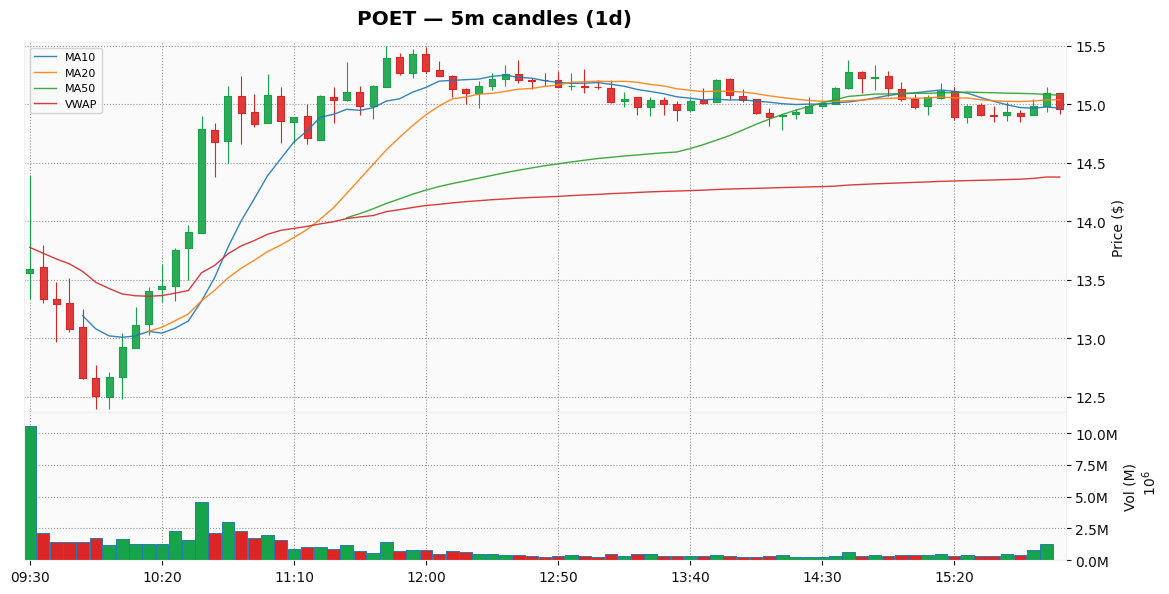

<div style='height:6px'></div>

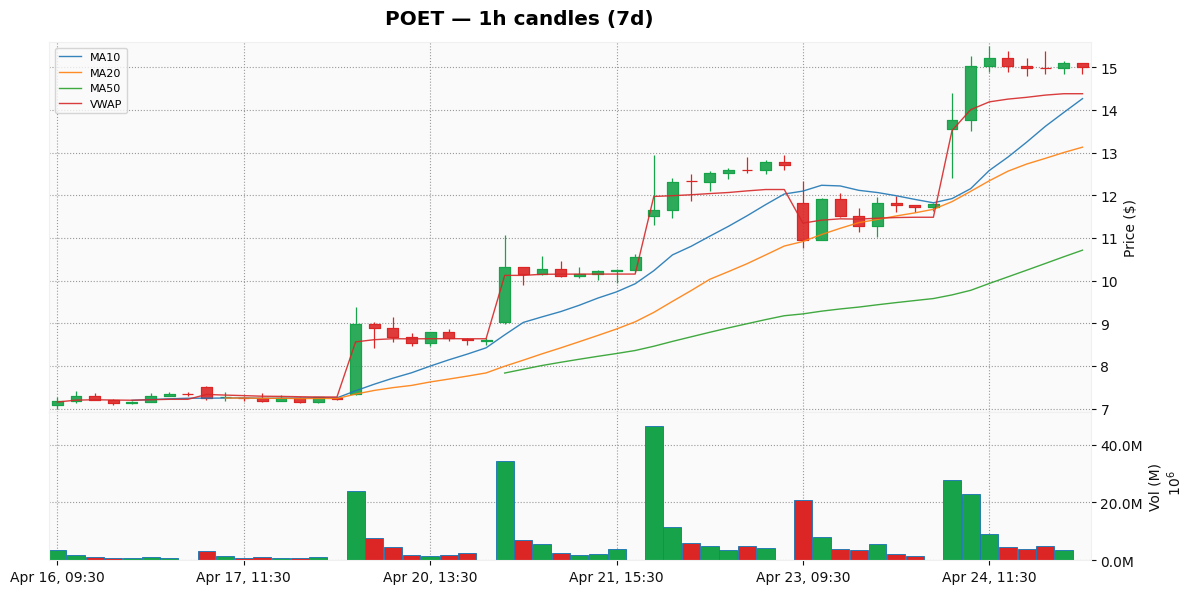

<div style='height:6px'></div>

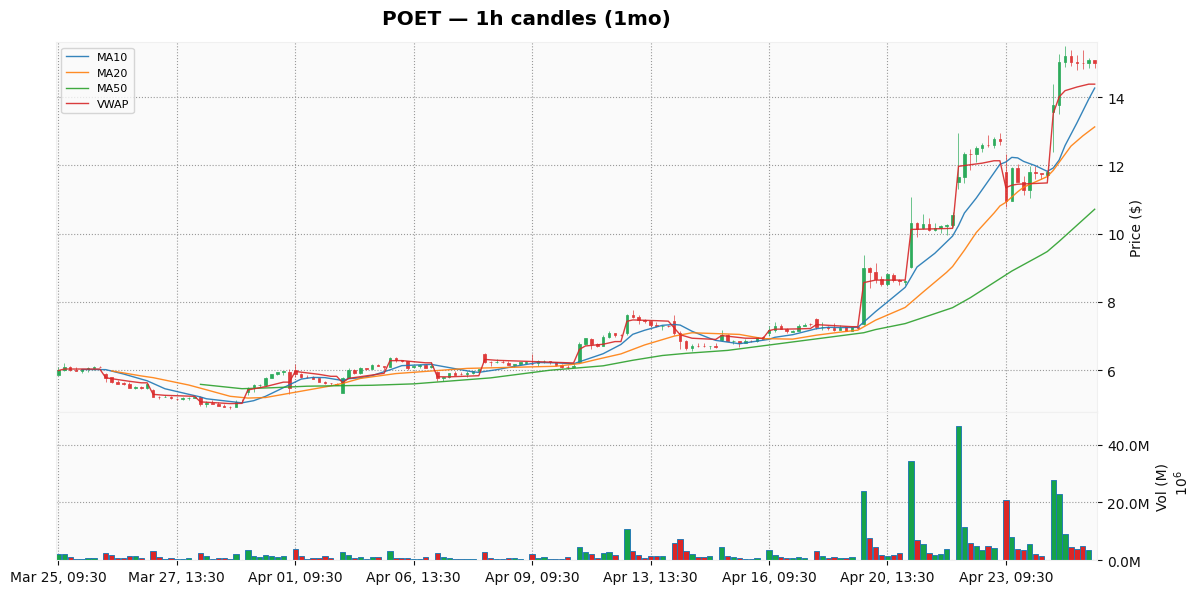

<hr style='margin:1.2rem 0'/>

##### SMCI - Super Micro Computer, Inc.

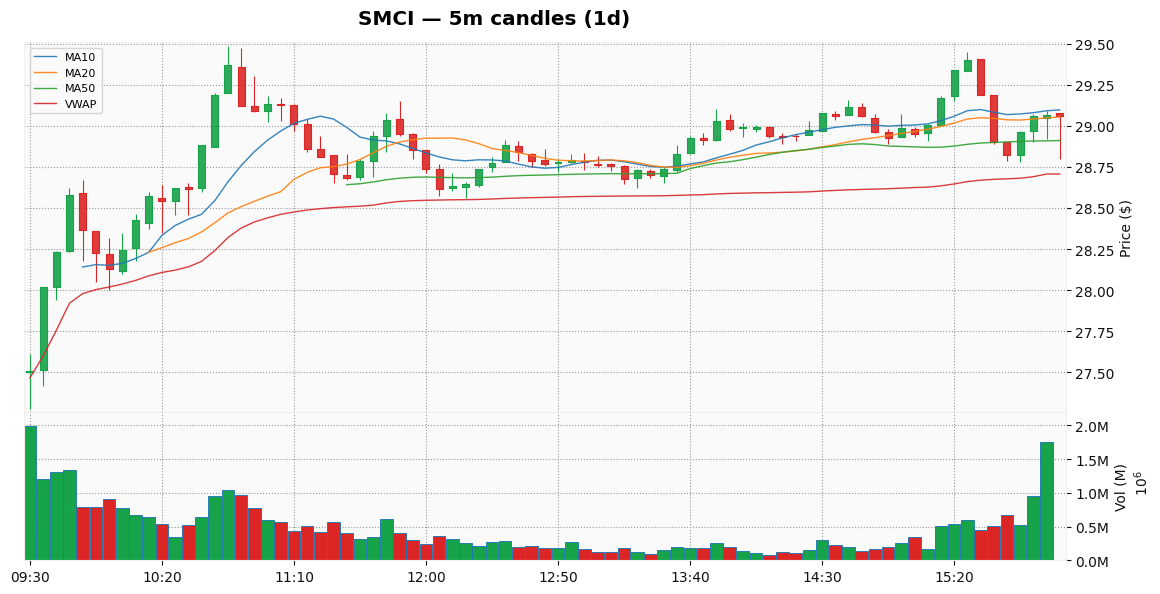

<div style='height:6px'></div>

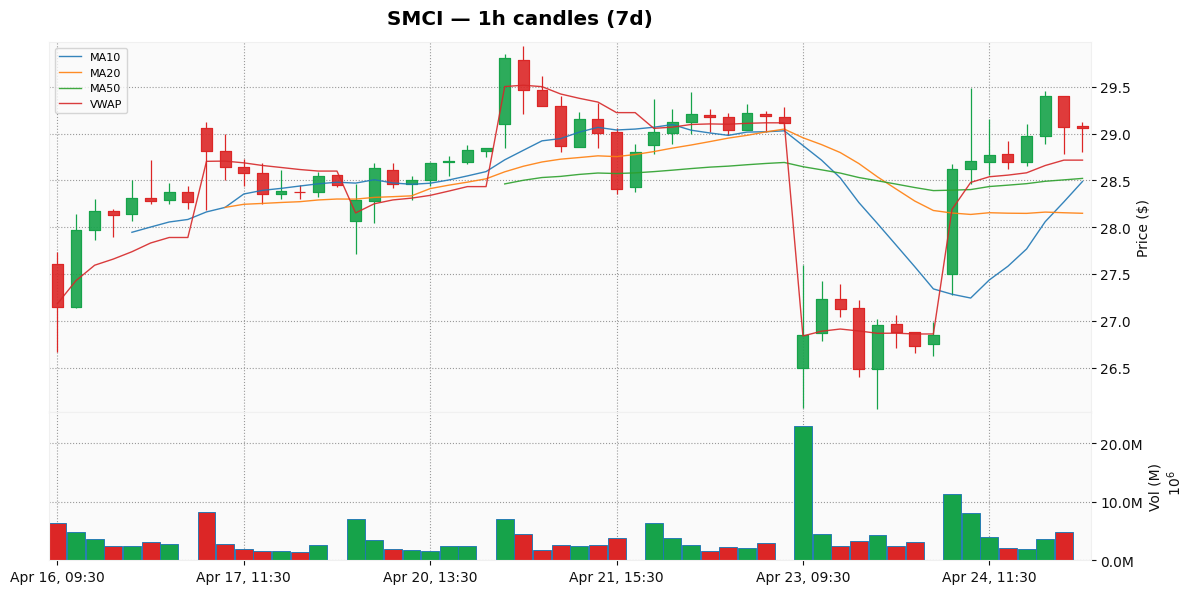

<div style='height:6px'></div>

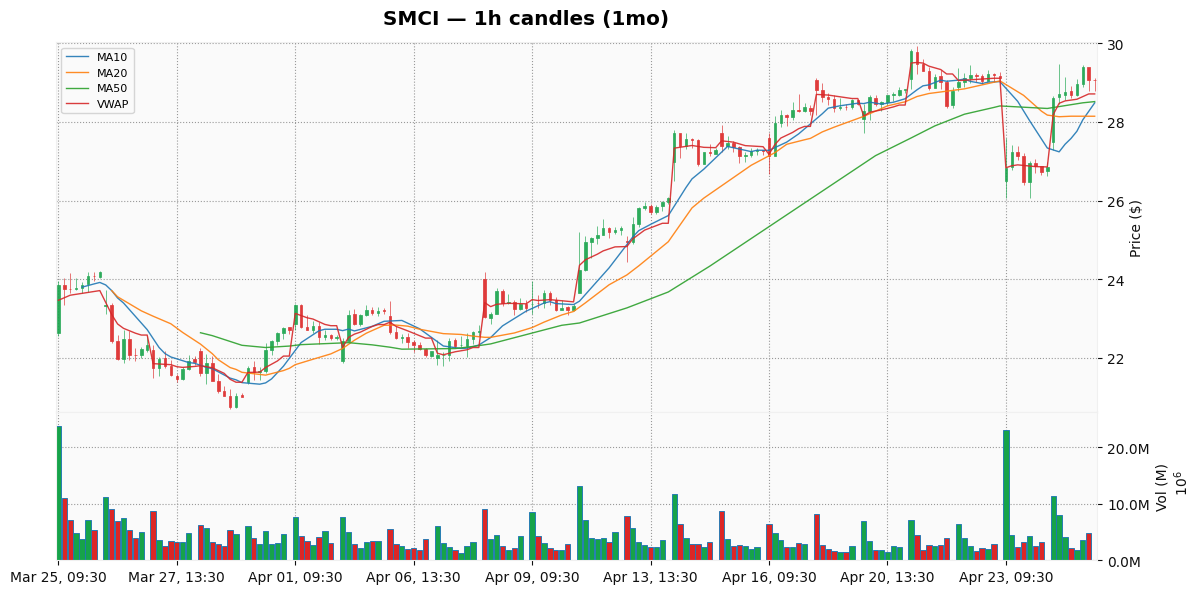

<hr style='margin:1.2rem 0'/>

##### NVTS - Navitas Semiconductor Corporation

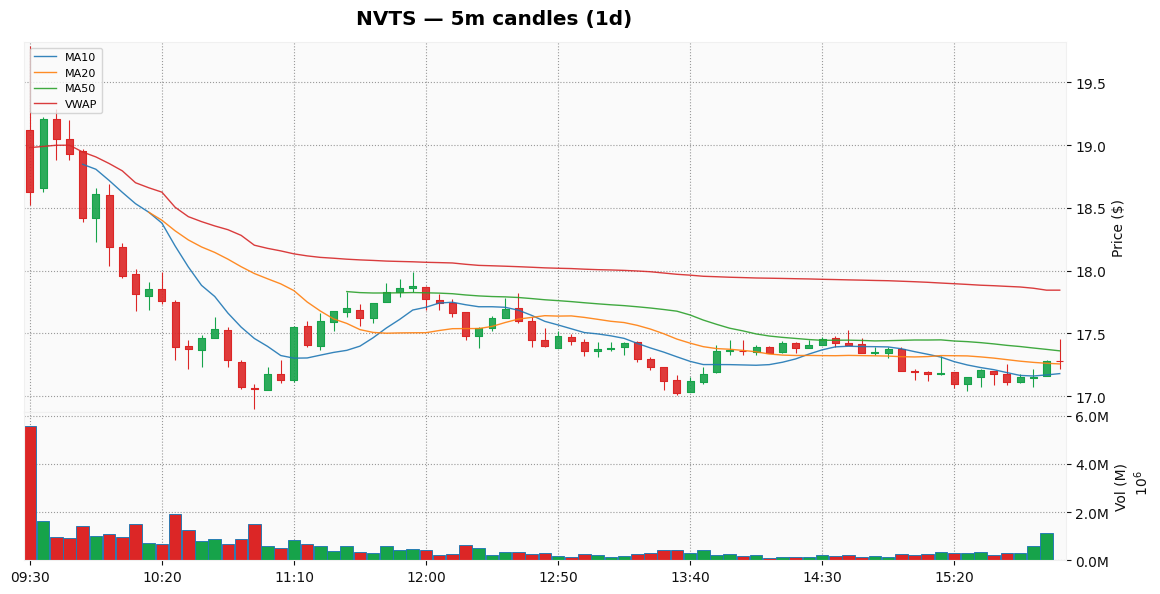

<div style='height:6px'></div>

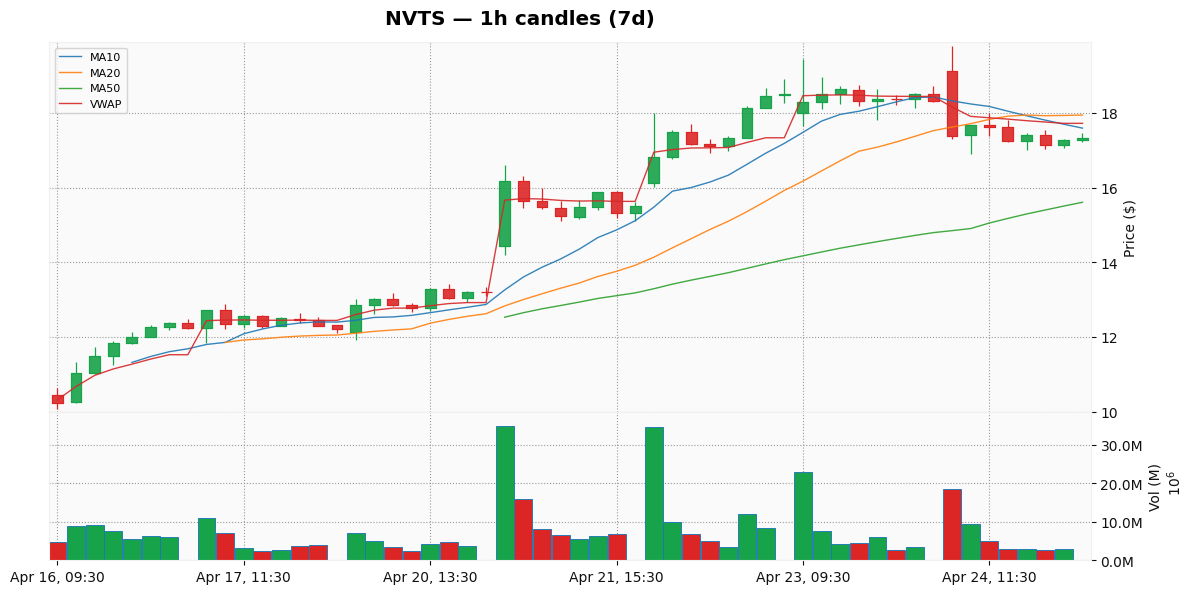

<div style='height:6px'></div>

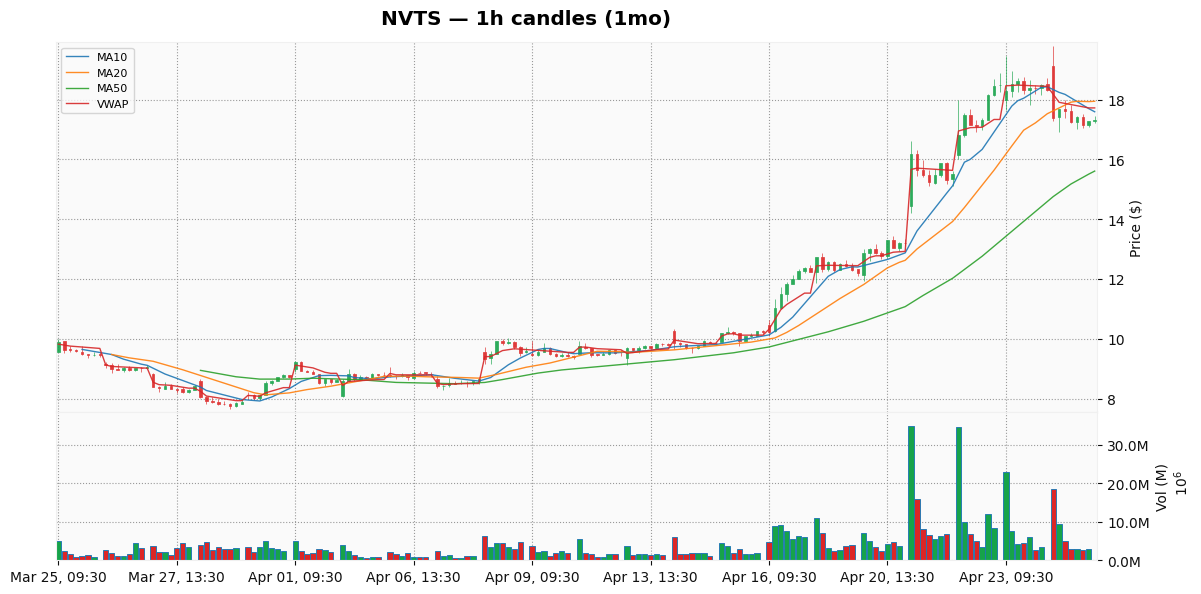

<hr style='margin:1.2rem 0'/>

##### SOXS - Direxion Daily Semiconductor Bear 3X ETF

SOXS: No earnings dates found, symbol may be delisted


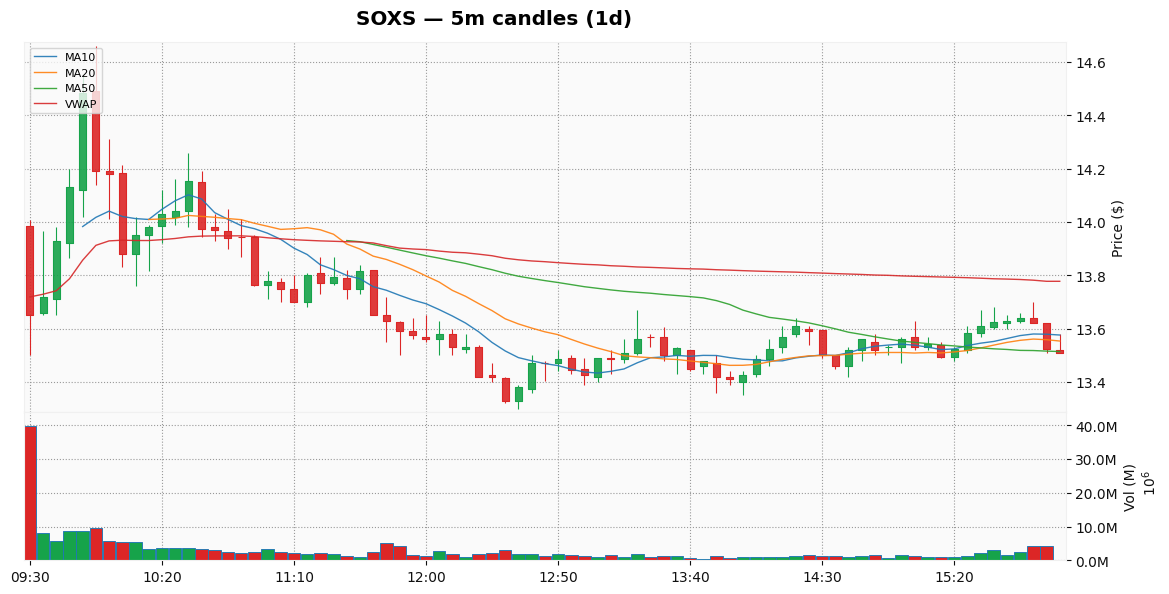

<div style='height:6px'></div>

SOXS: No earnings dates found, symbol may be delisted


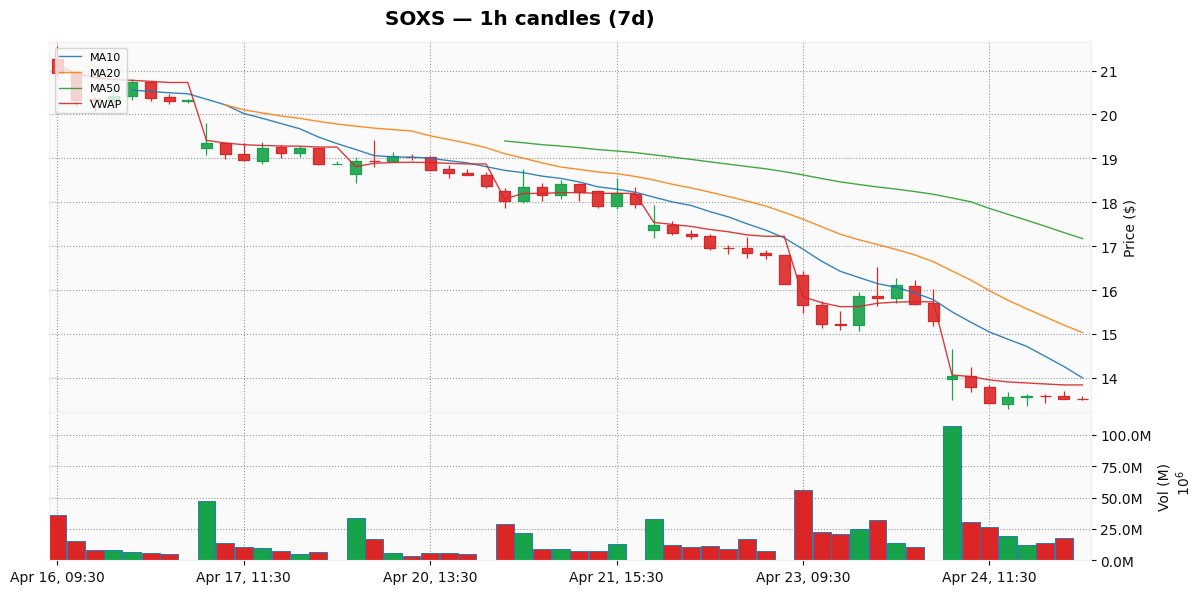

<div style='height:6px'></div>

SOXS: No earnings dates found, symbol may be delisted


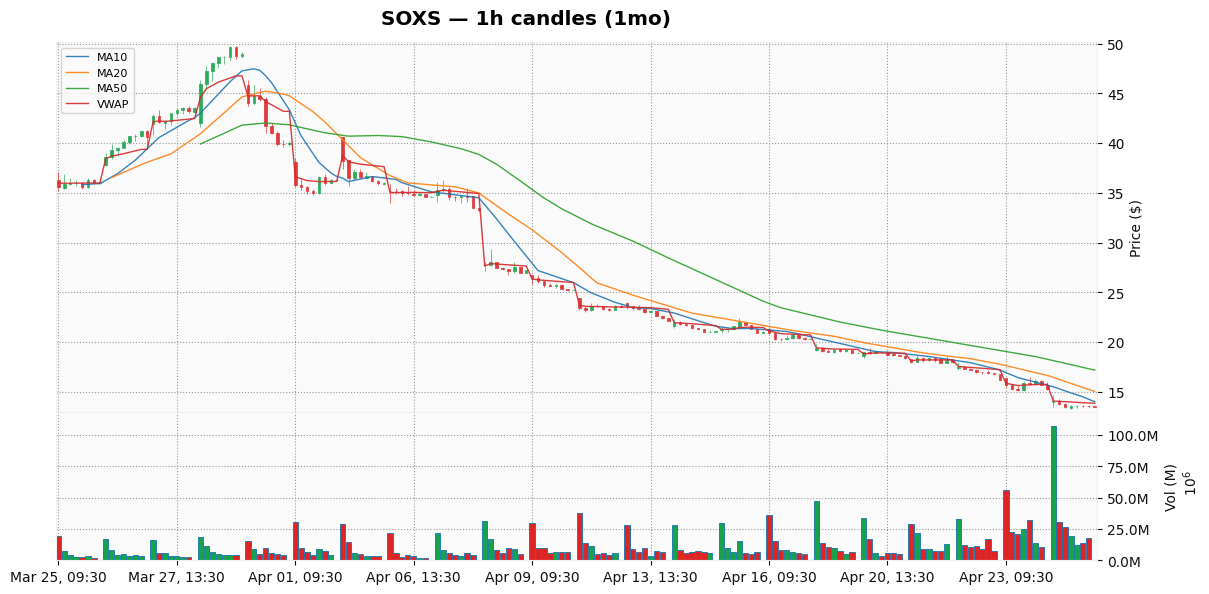

<hr style='margin:1.2rem 0'/>

##### CMCSA - Comcast Corporation

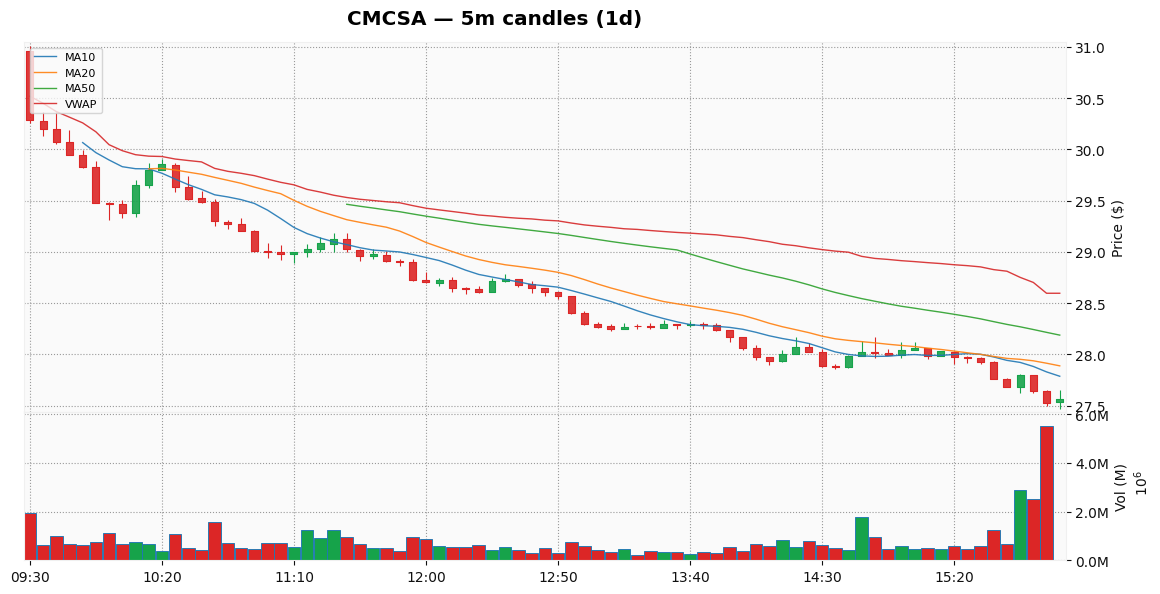

<div style='height:6px'></div>

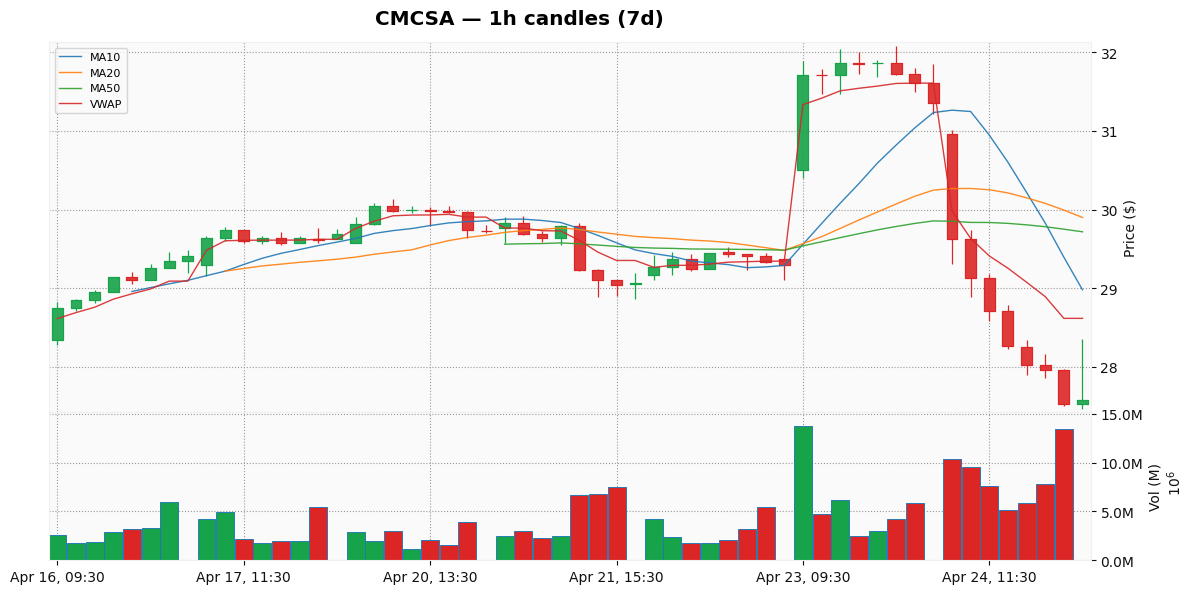

<div style='height:6px'></div>

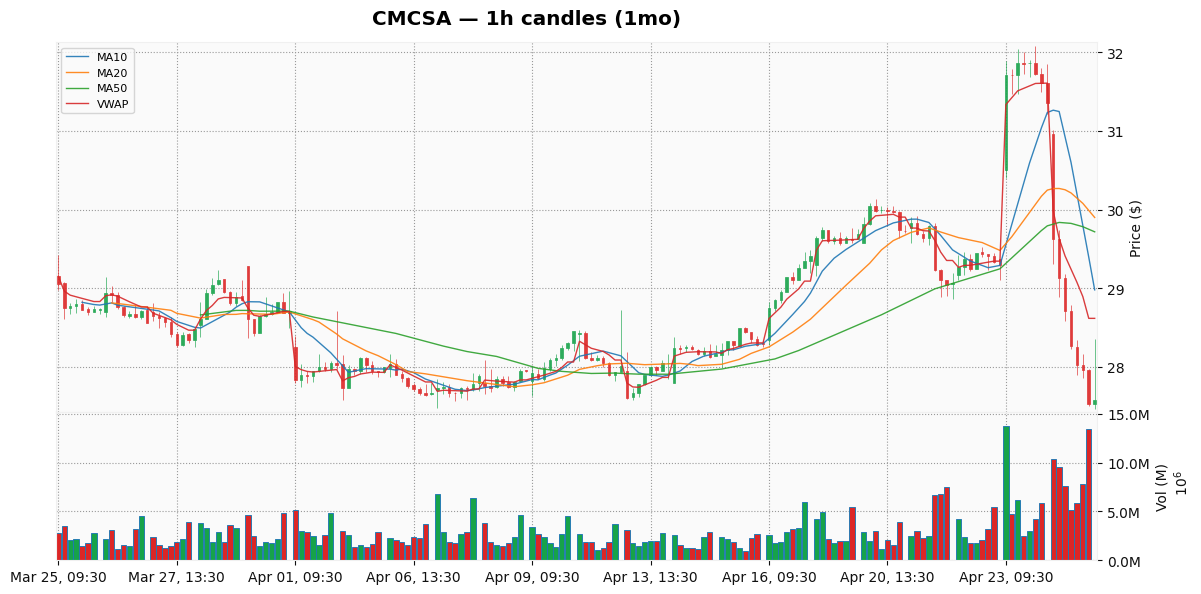

<hr style='margin:1.2rem 0'/>

##### ARMG - Leverage Shares 2x Long ARM Daily ETF

ARMG: No earnings dates found, symbol may be delisted


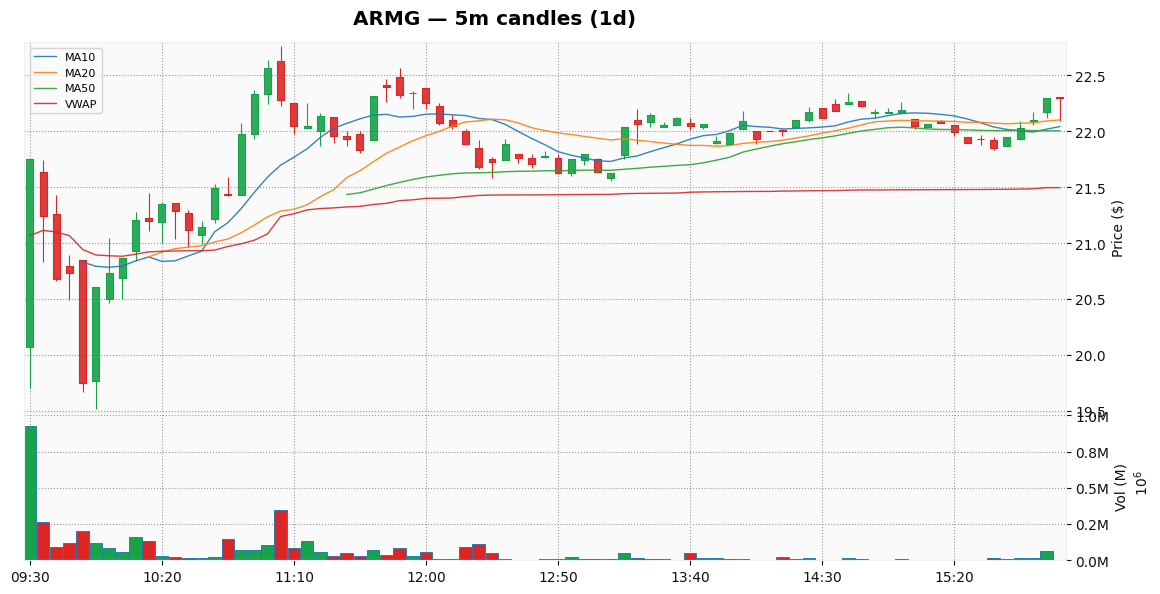

<div style='height:6px'></div>

ARMG: No earnings dates found, symbol may be delisted


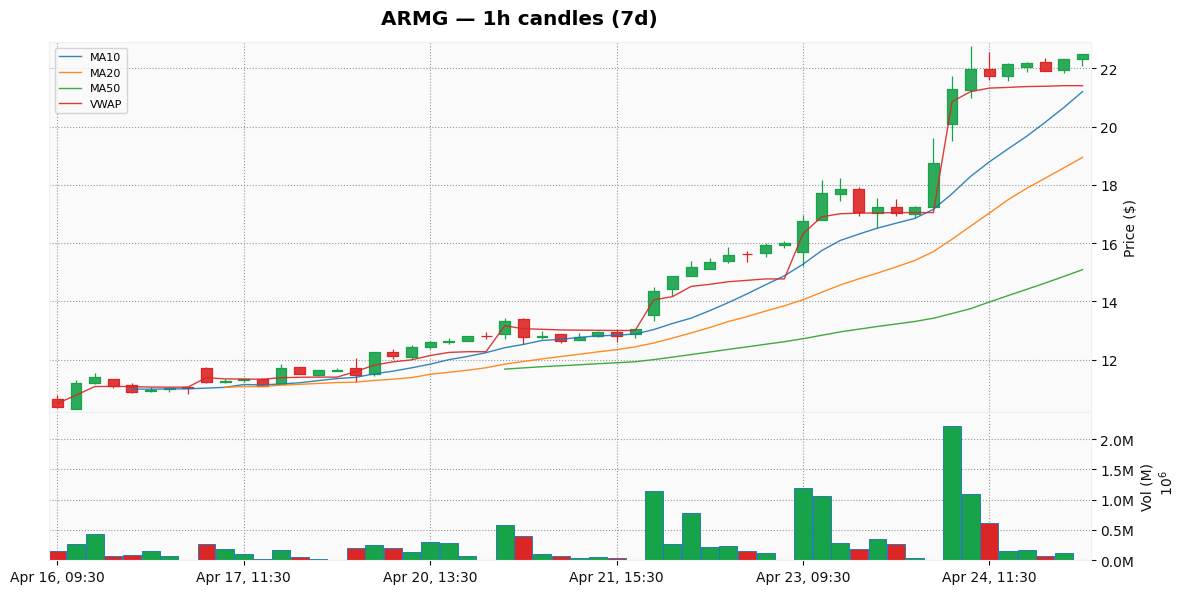

<div style='height:6px'></div>

ARMG: No earnings dates found, symbol may be delisted


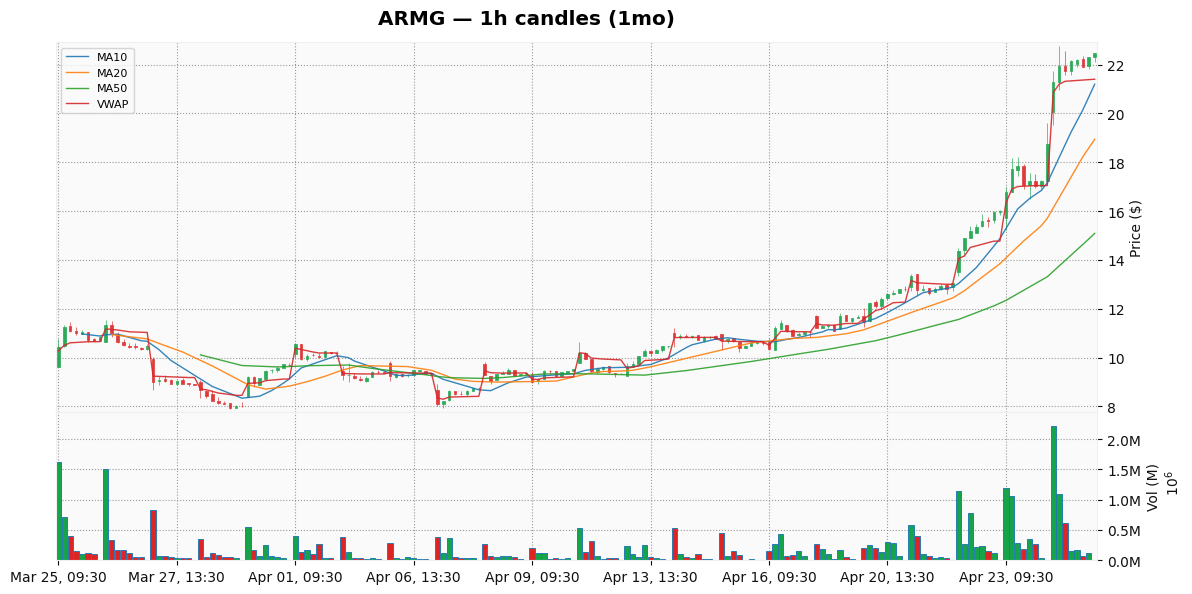

<hr style='margin:1.2rem 0'/>

##### POET - POET Technologies Inc.

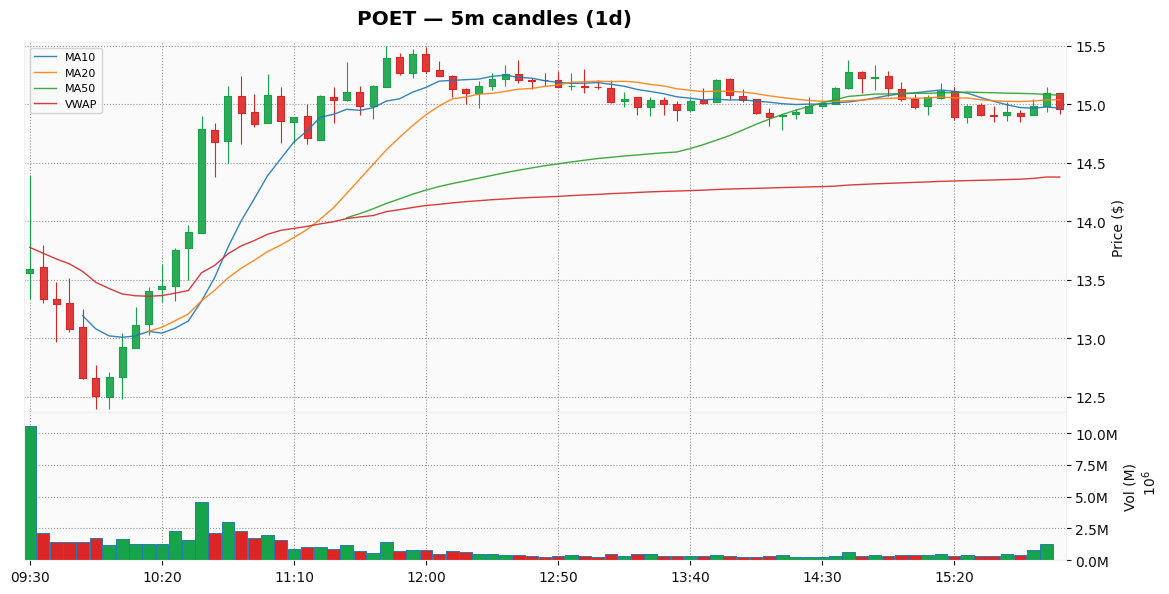

<div style='height:6px'></div>

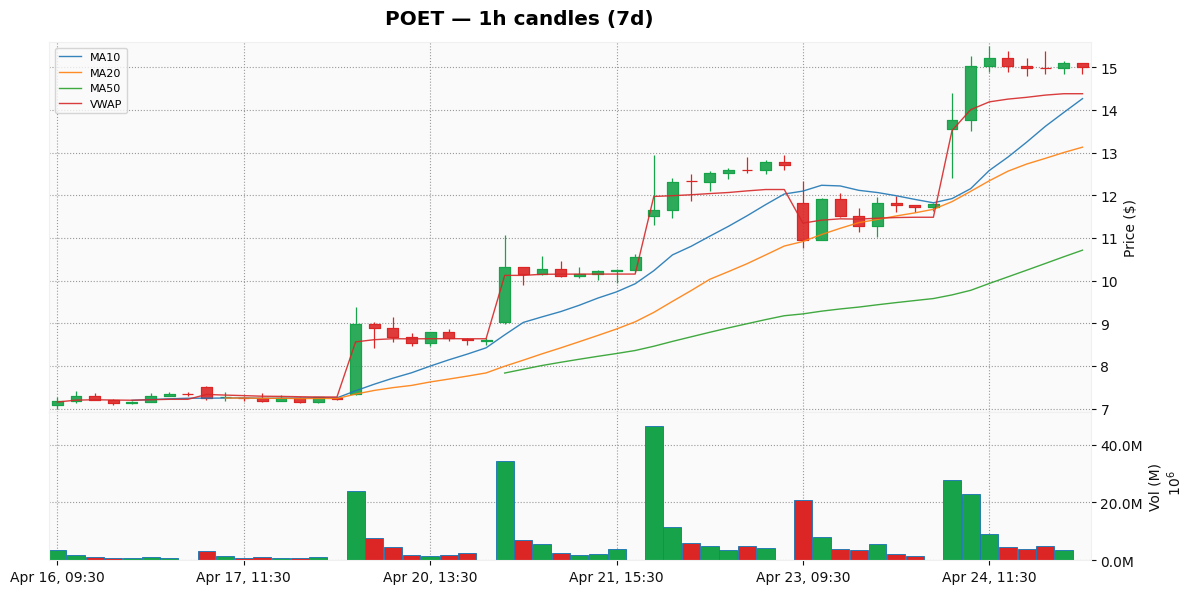

<div style='height:6px'></div>

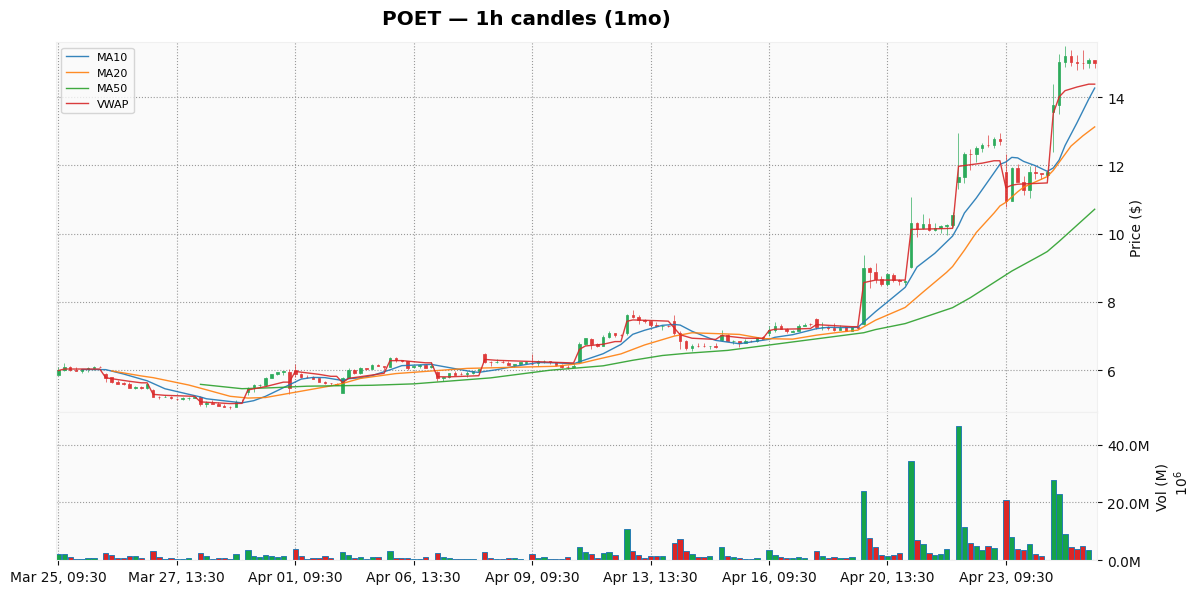

<hr style='margin:1.2rem 0'/>

##### AKAN - Akanda Corp.

AKAN: No earnings dates found, symbol may be delisted


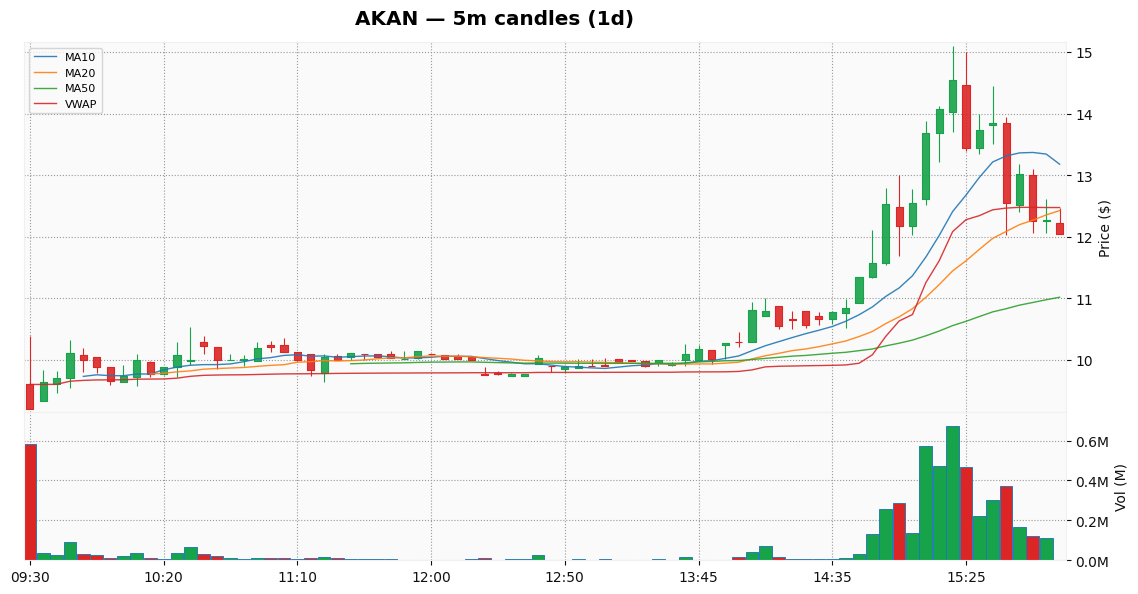

<div style='height:6px'></div>

AKAN: No earnings dates found, symbol may be delisted


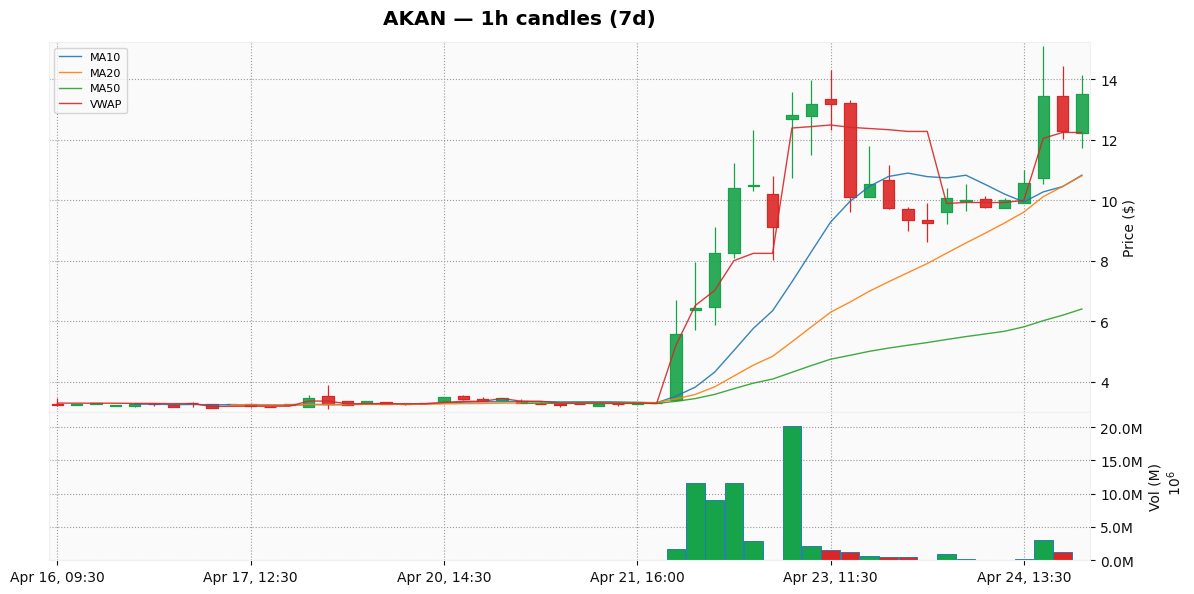

<div style='height:6px'></div>

AKAN: No earnings dates found, symbol may be delisted


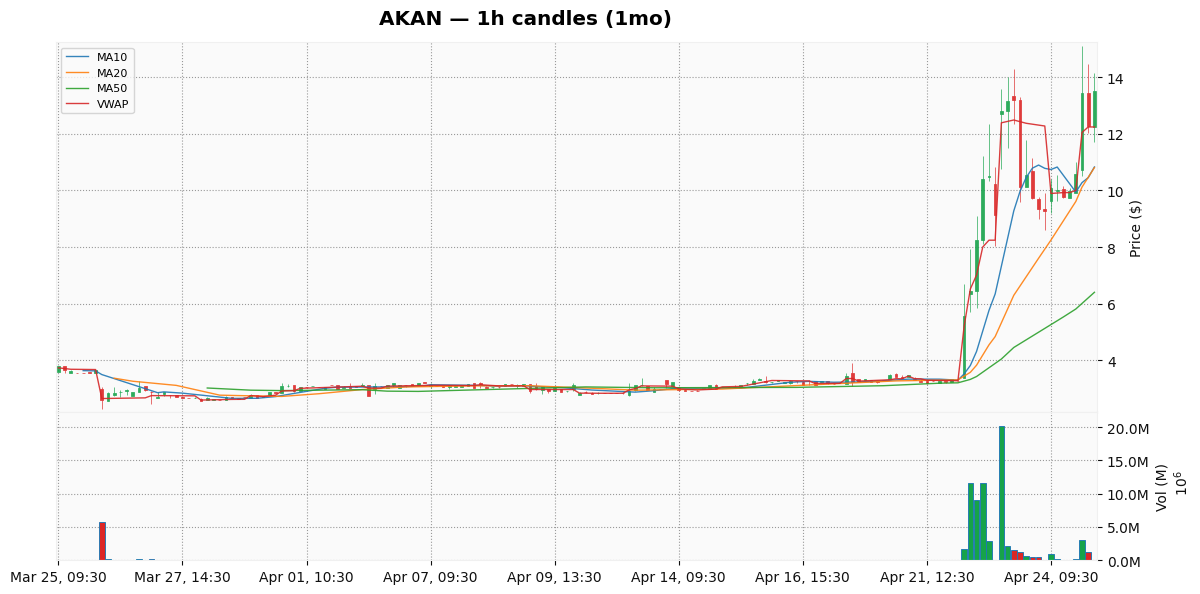

<hr style='margin:1.2rem 0'/>

##### QCML - GraniteShares 2x Long QCOM Daily ETF

QCML: No earnings dates found, symbol may be delisted


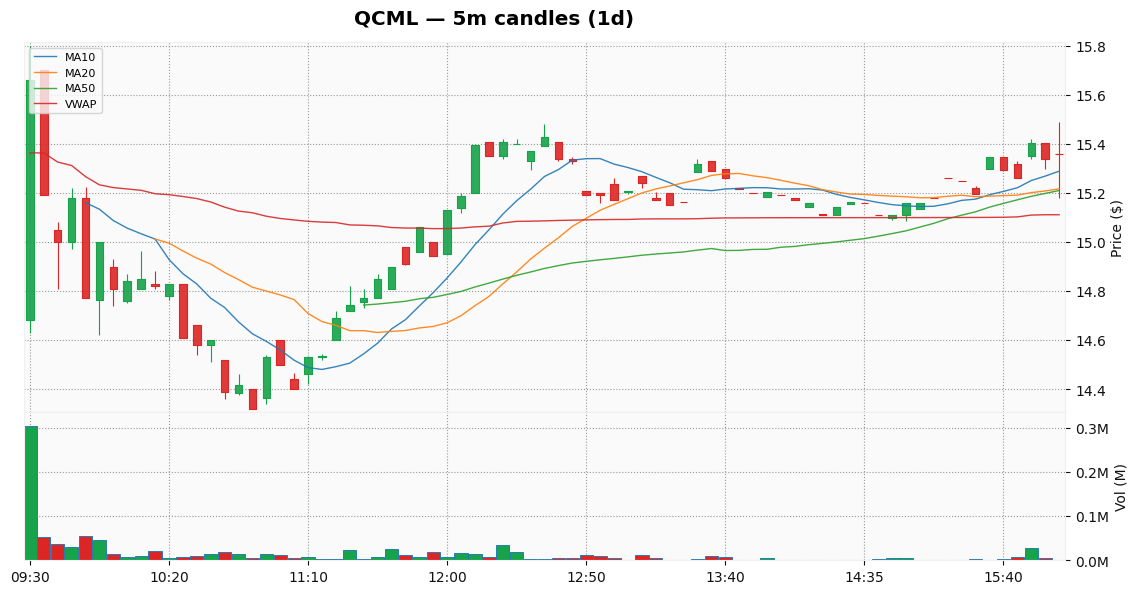

<div style='height:6px'></div>

QCML: No earnings dates found, symbol may be delisted


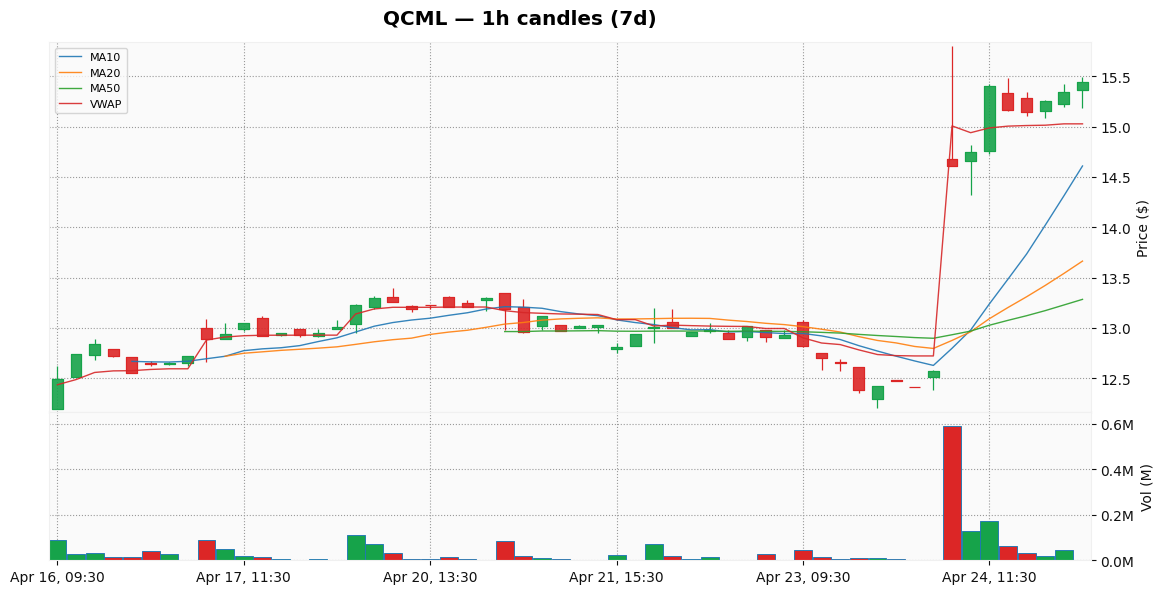

<div style='height:6px'></div>

QCML: No earnings dates found, symbol may be delisted


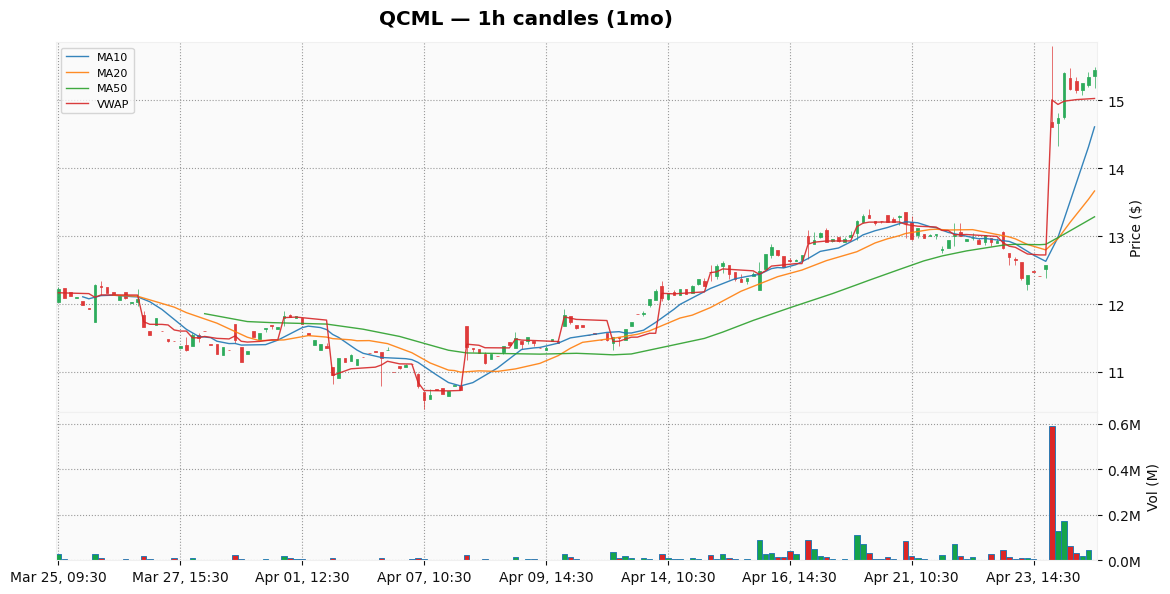

<hr style='margin:1.2rem 0'/>

##### TRT - Trio-Tech International

TRT: No earnings dates found, symbol may be delisted


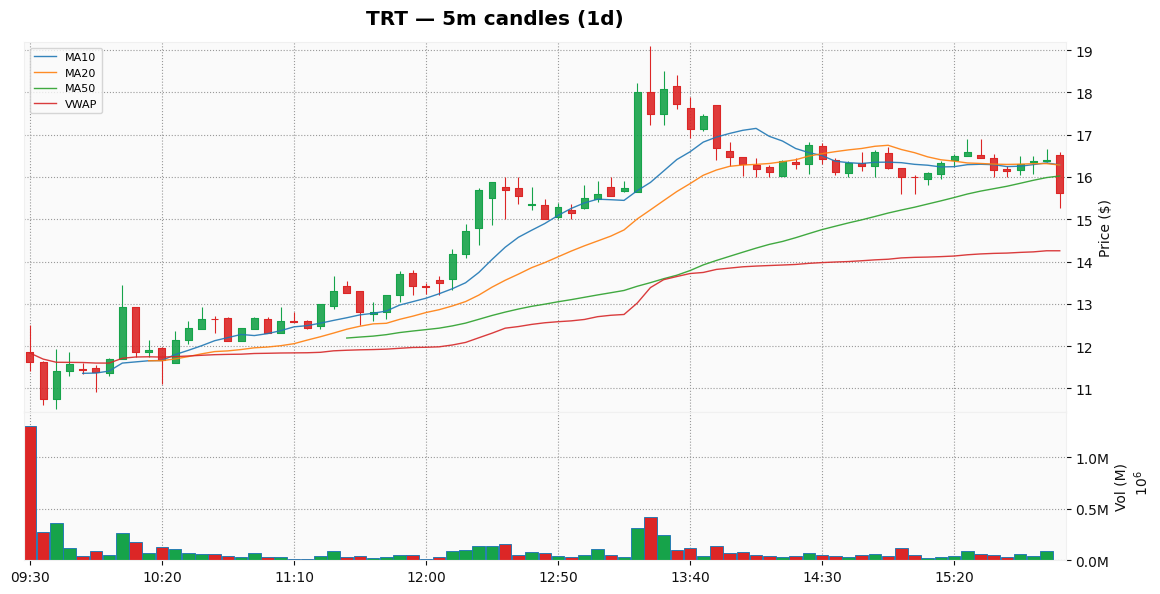

<div style='height:6px'></div>

TRT: No earnings dates found, symbol may be delisted


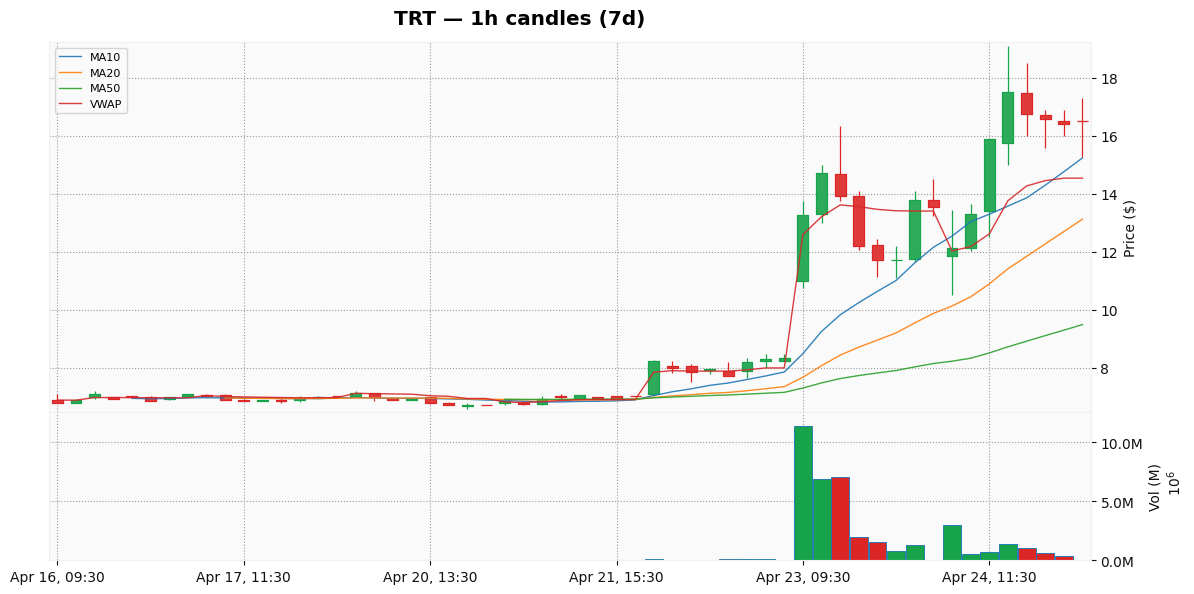

<div style='height:6px'></div>

TRT: No earnings dates found, symbol may be delisted


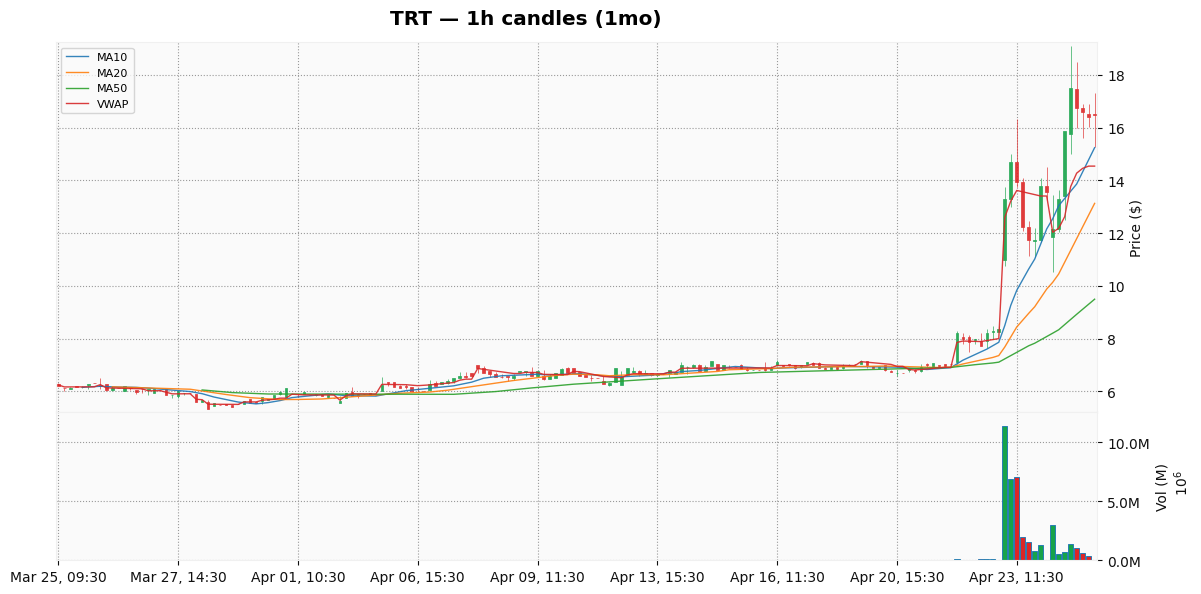

<hr style='margin:1.2rem 0'/>

##### OGN - Organon & Co.

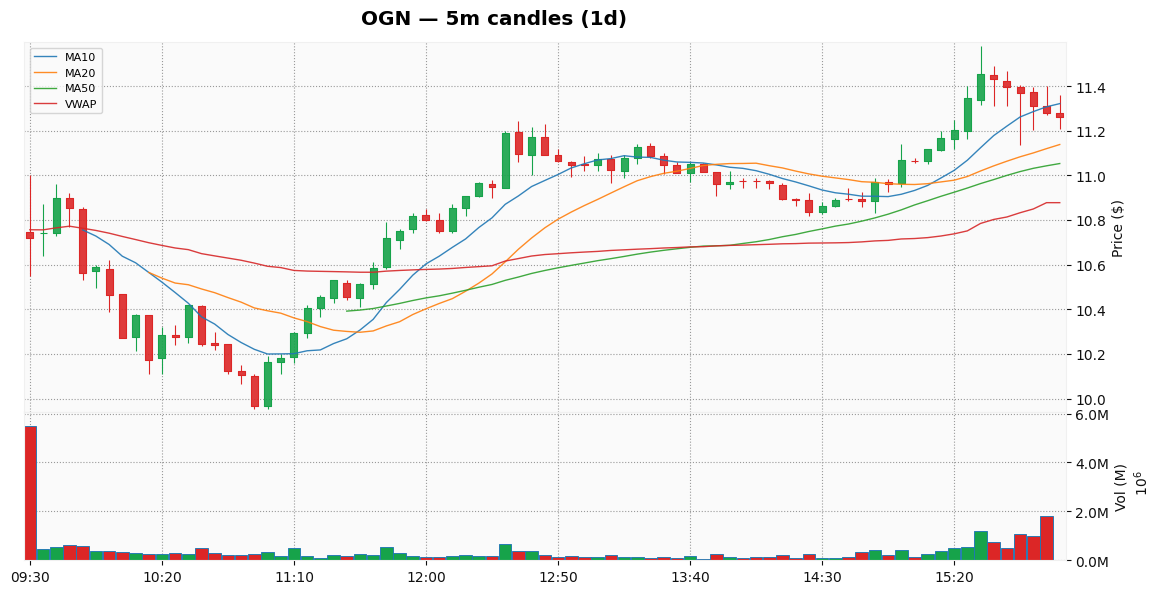

<div style='height:6px'></div>

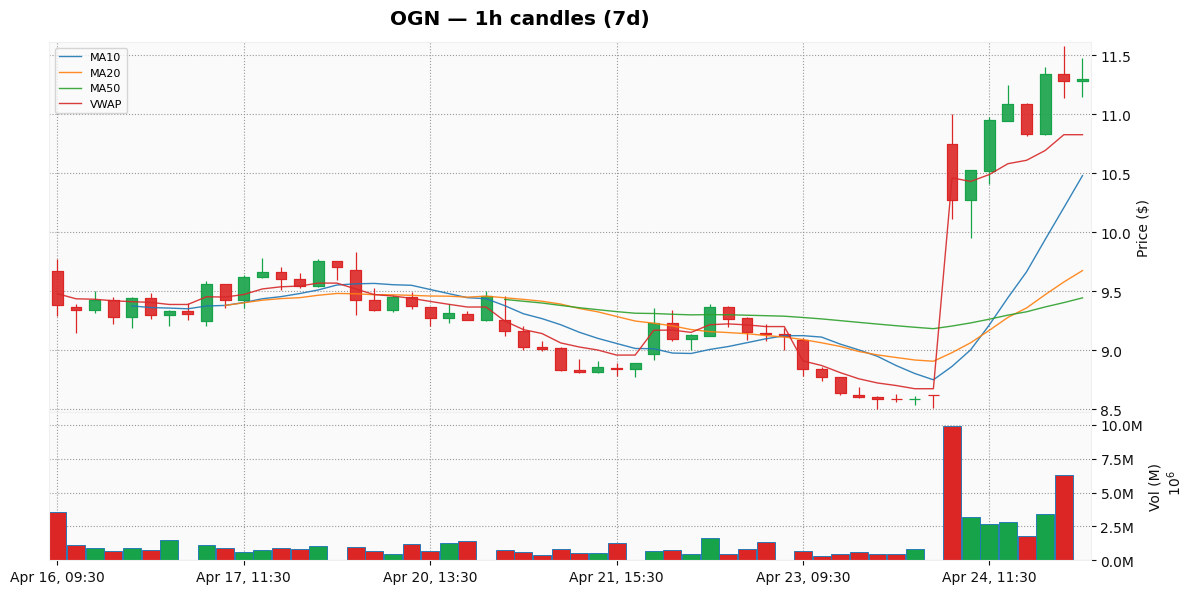

<div style='height:6px'></div>

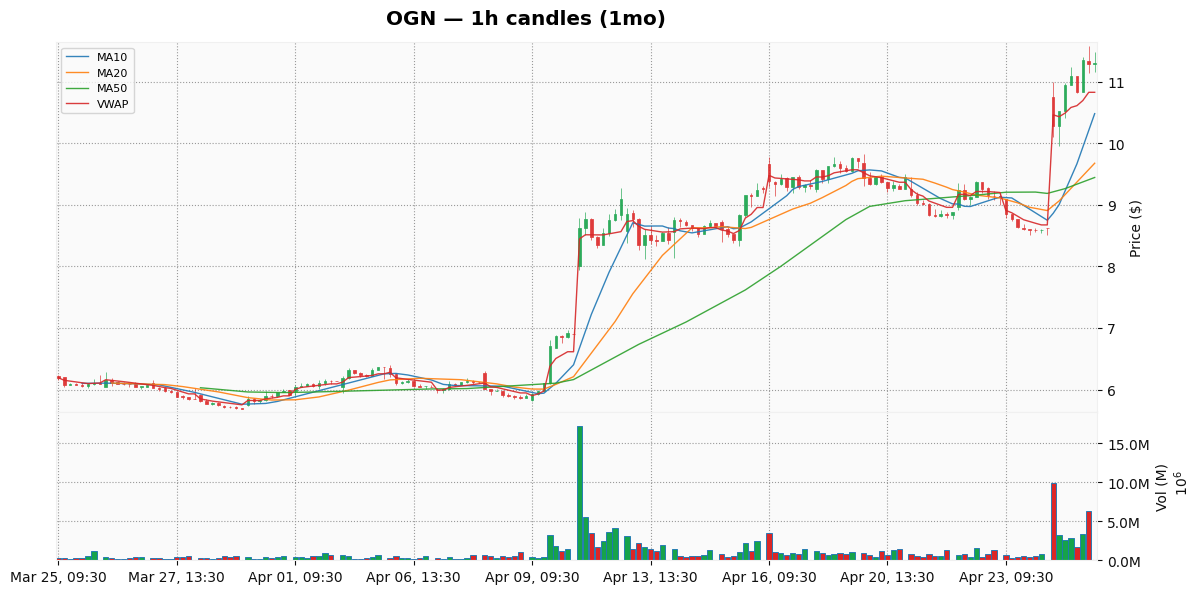

<hr style='margin:1.2rem 0'/>

##### ATOM - Atomera Incorporated

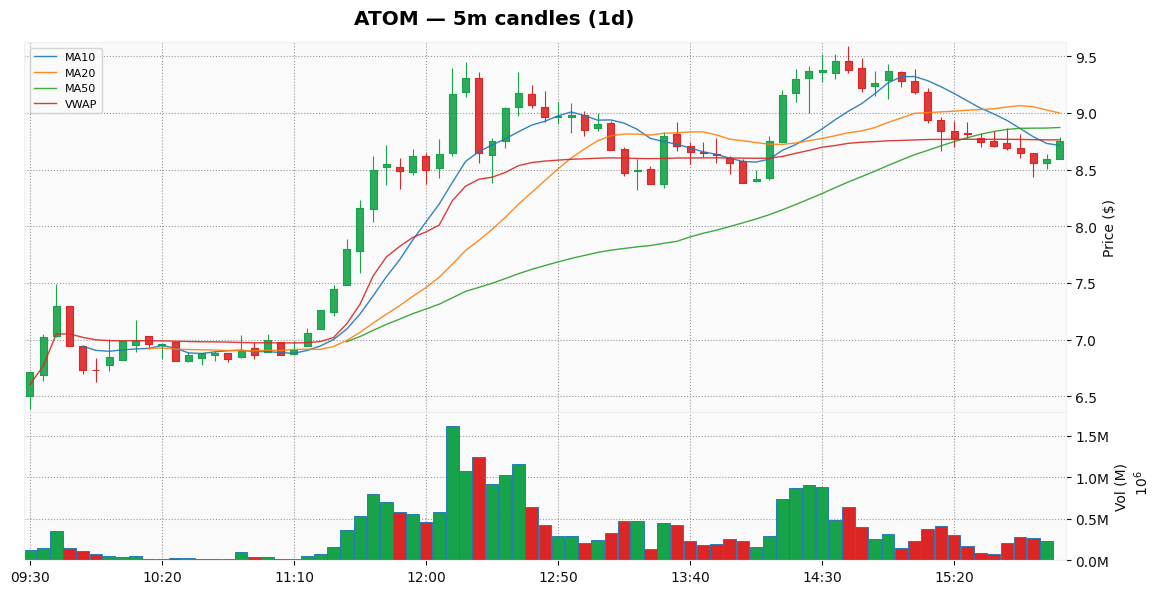

<div style='height:6px'></div>

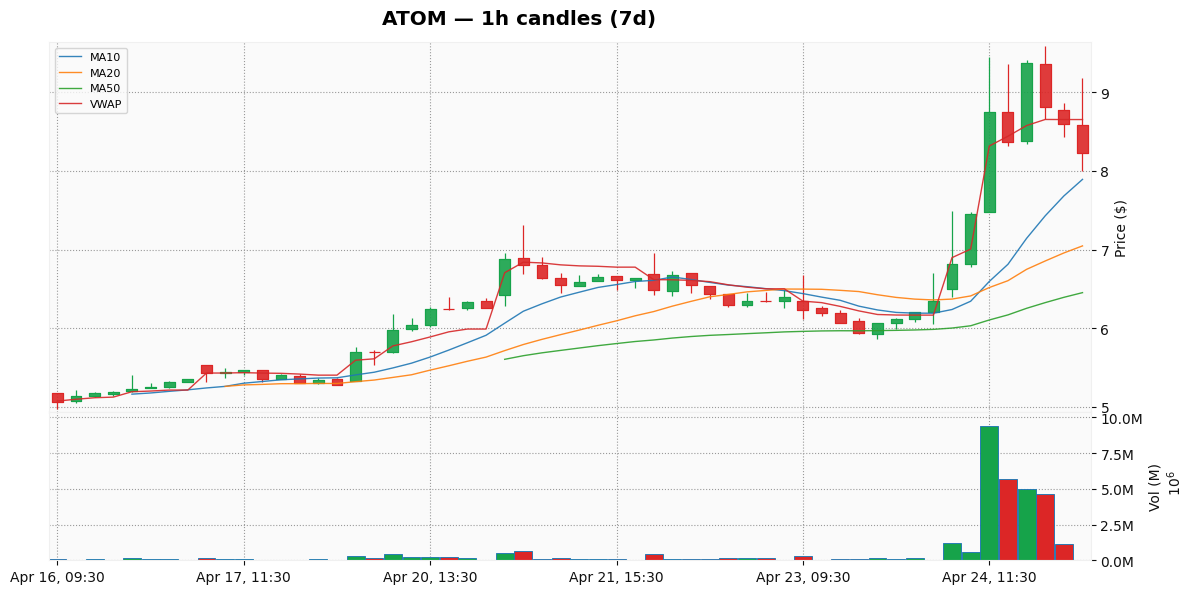

<div style='height:6px'></div>

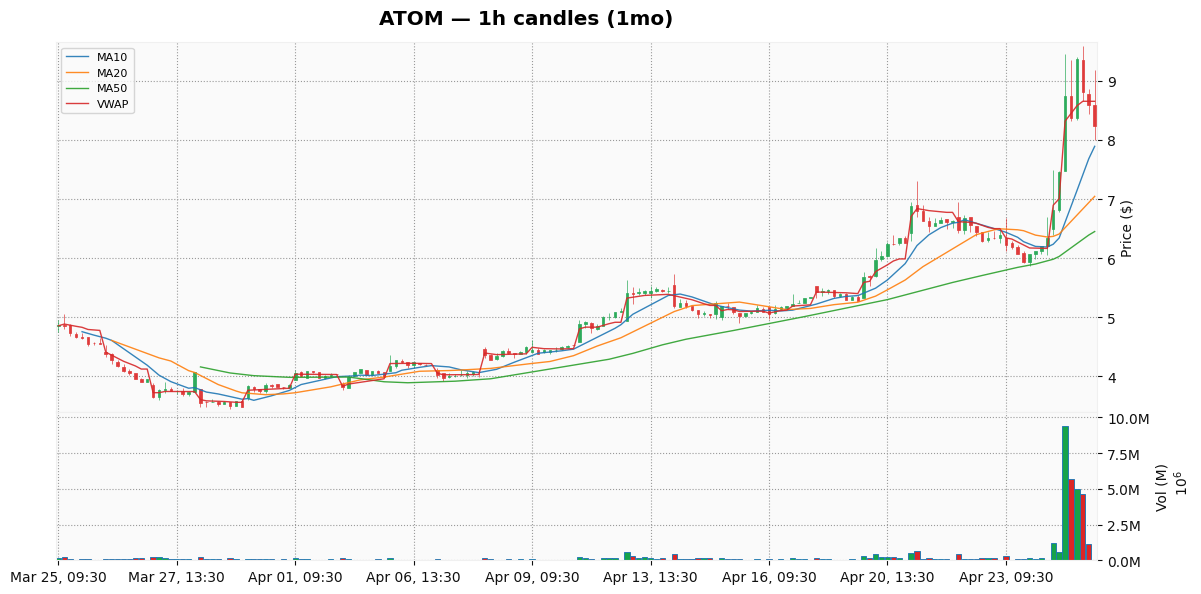

<hr style='margin:1.2rem 0'/>

##### RMAX - RE/MAX Holdings, Inc.

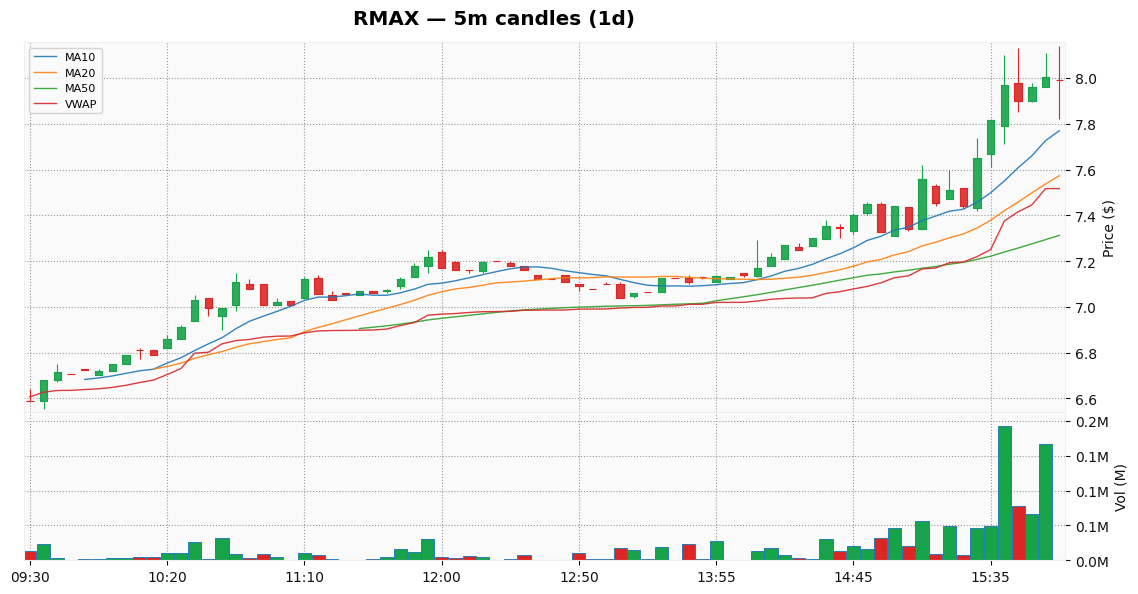

<div style='height:6px'></div>

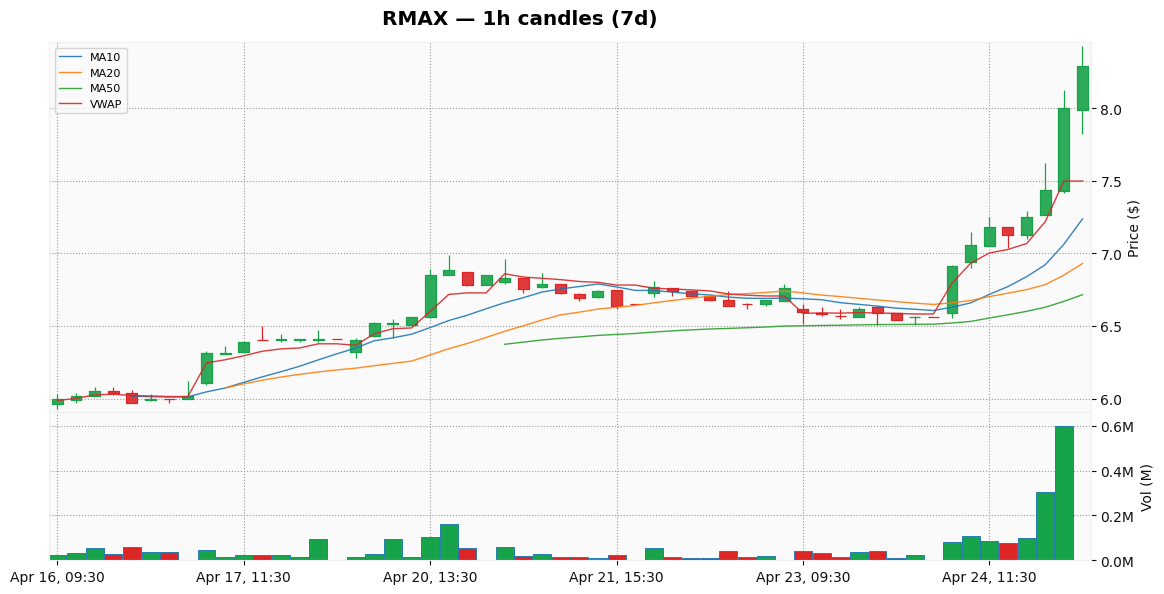

<div style='height:6px'></div>

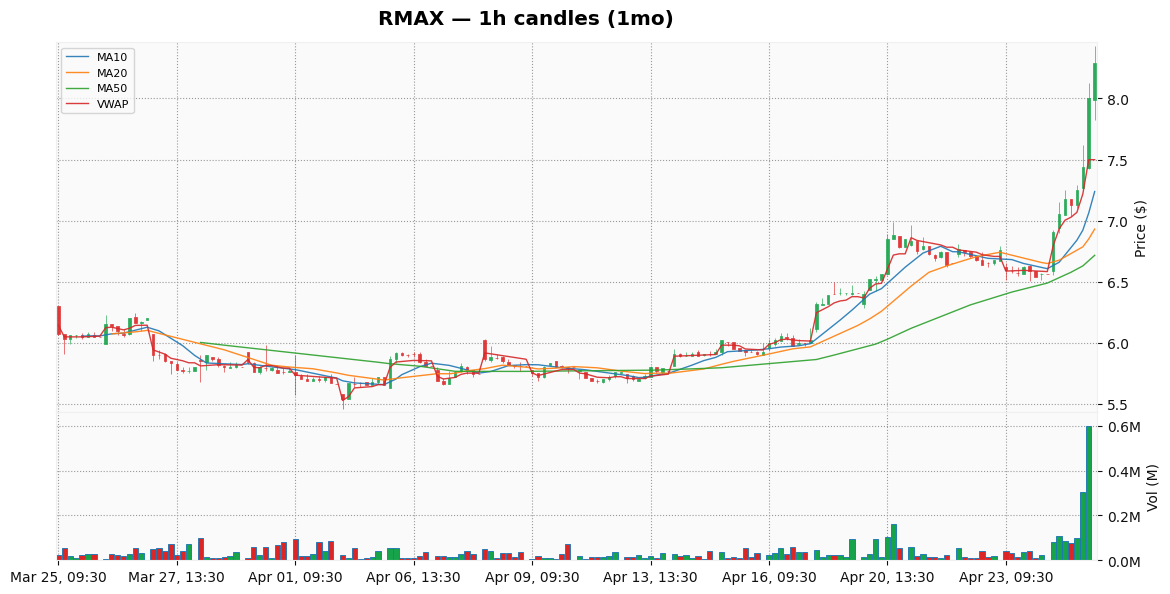

<hr style='margin:1.2rem 0'/>

##### SKLZ - Skillz Inc.

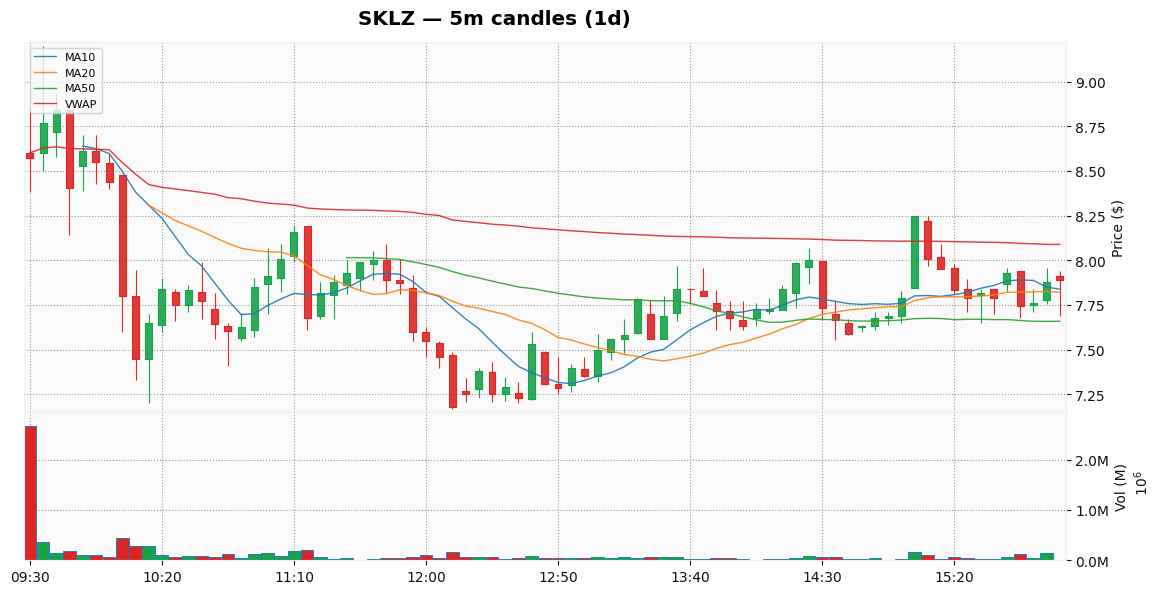

<div style='height:6px'></div>

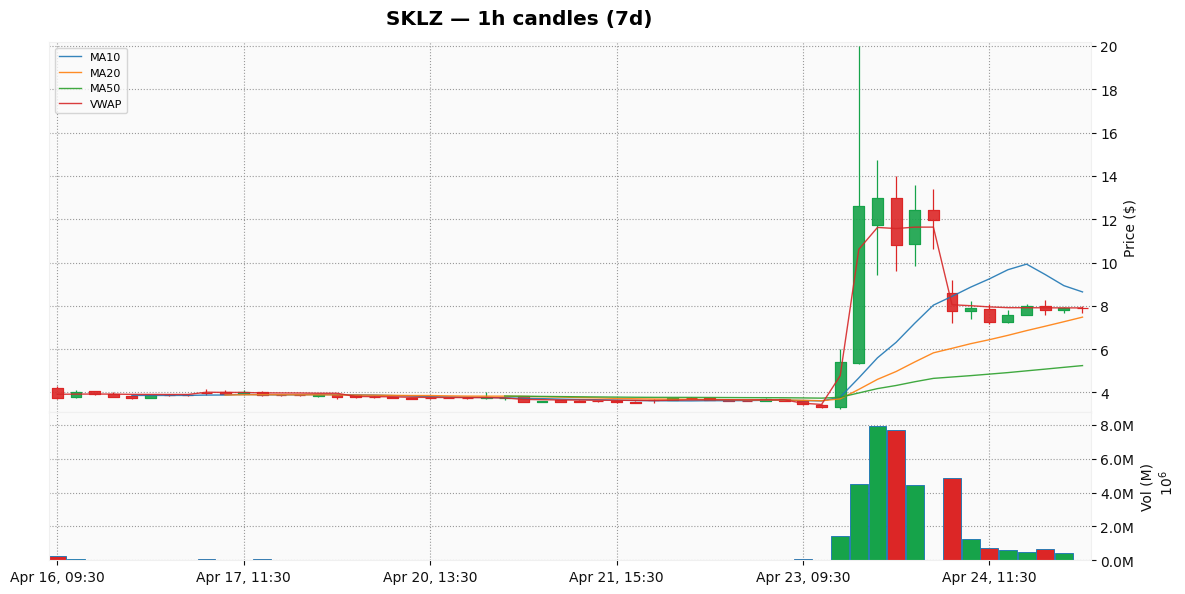

<div style='height:6px'></div>

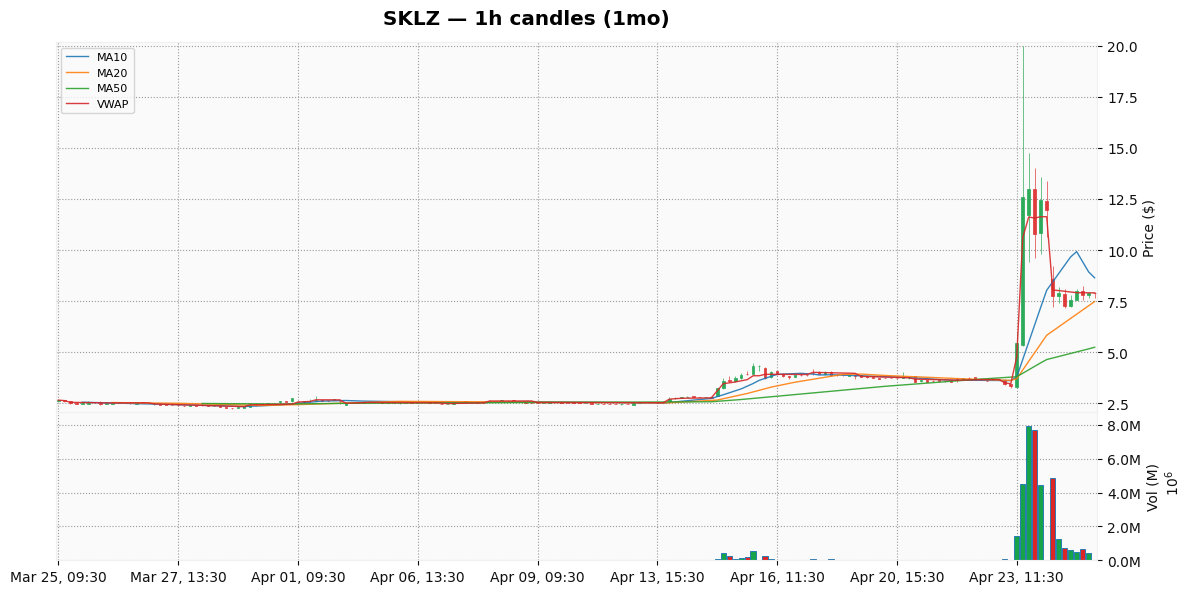

<hr style='margin:1.2rem 0'/>

##### CMCSA - Comcast Corporation

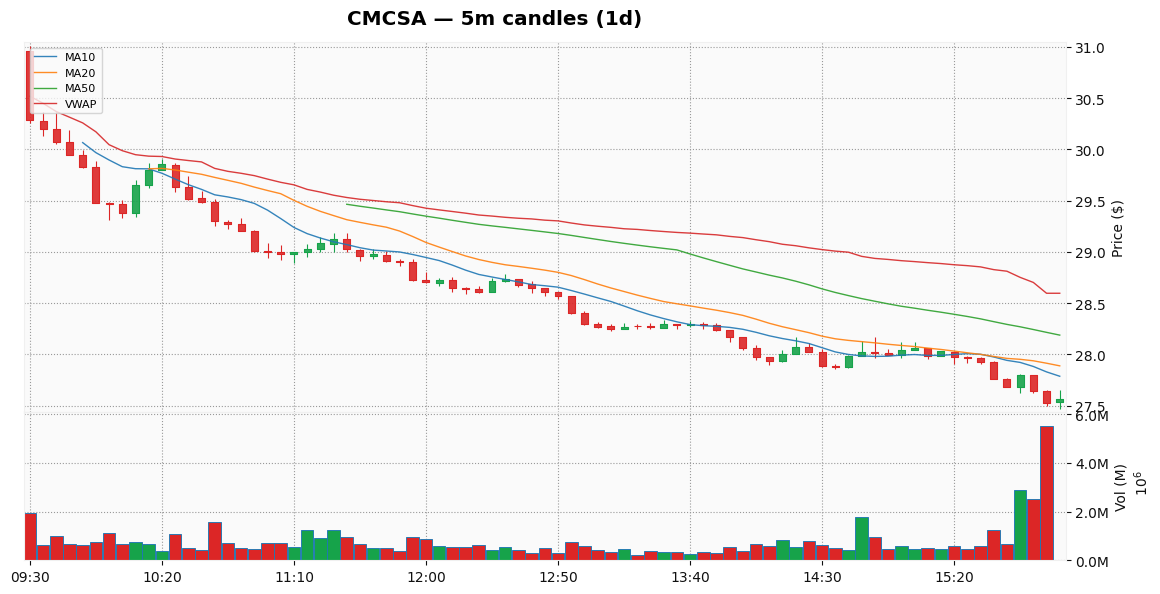

<div style='height:6px'></div>

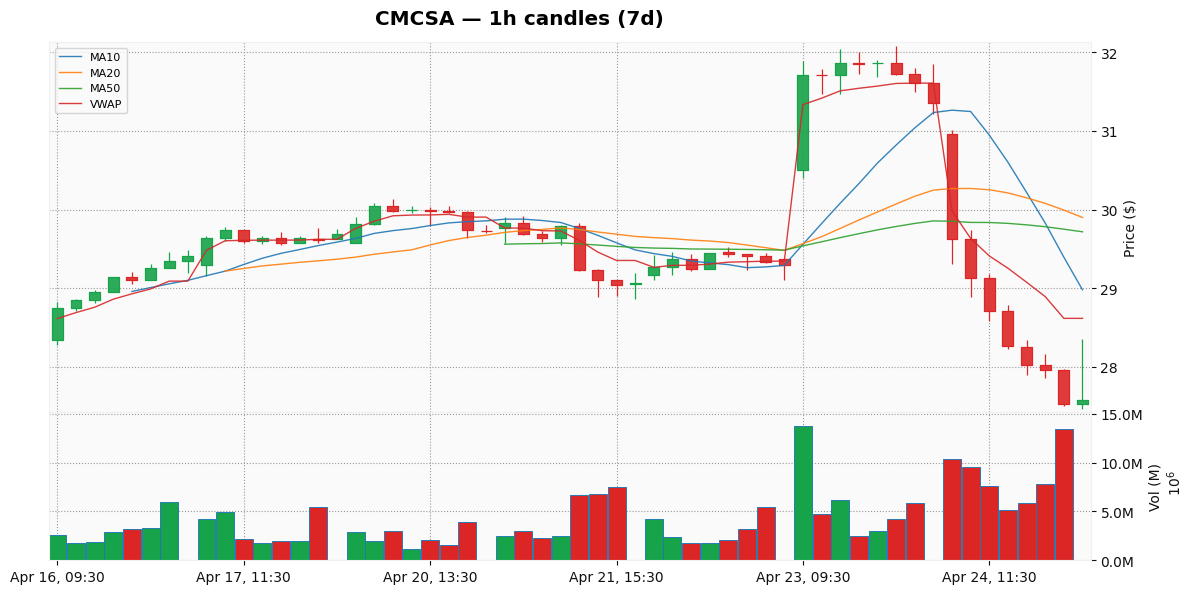

<div style='height:6px'></div>

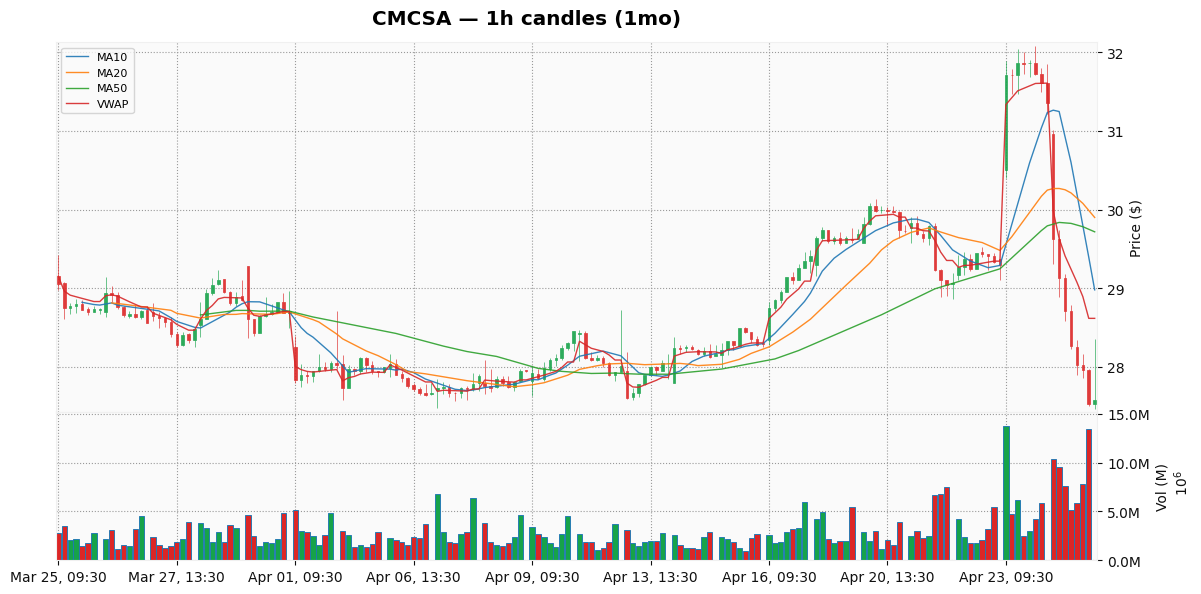

<hr style='margin:1.2rem 0'/>

##### STNE - StoneCo Ltd.

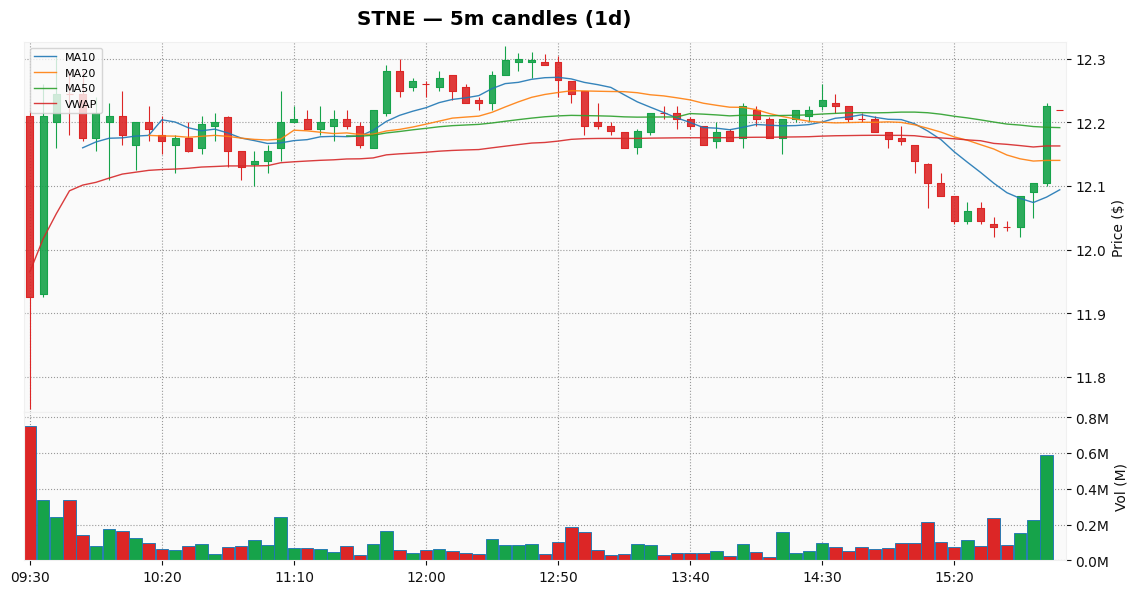

<div style='height:6px'></div>

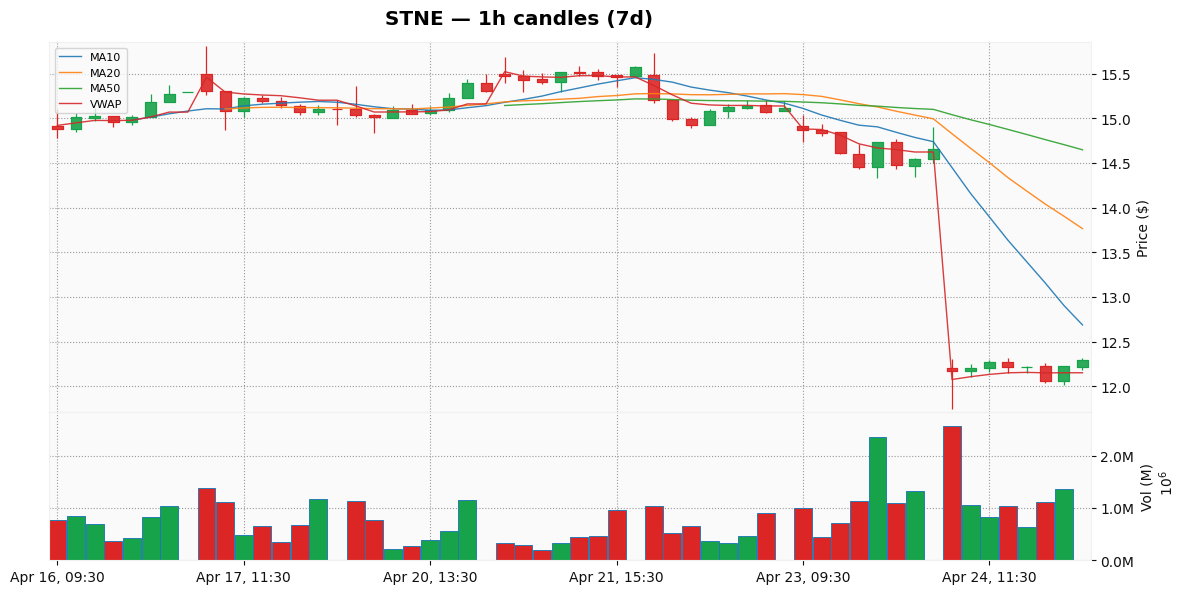

<div style='height:6px'></div>

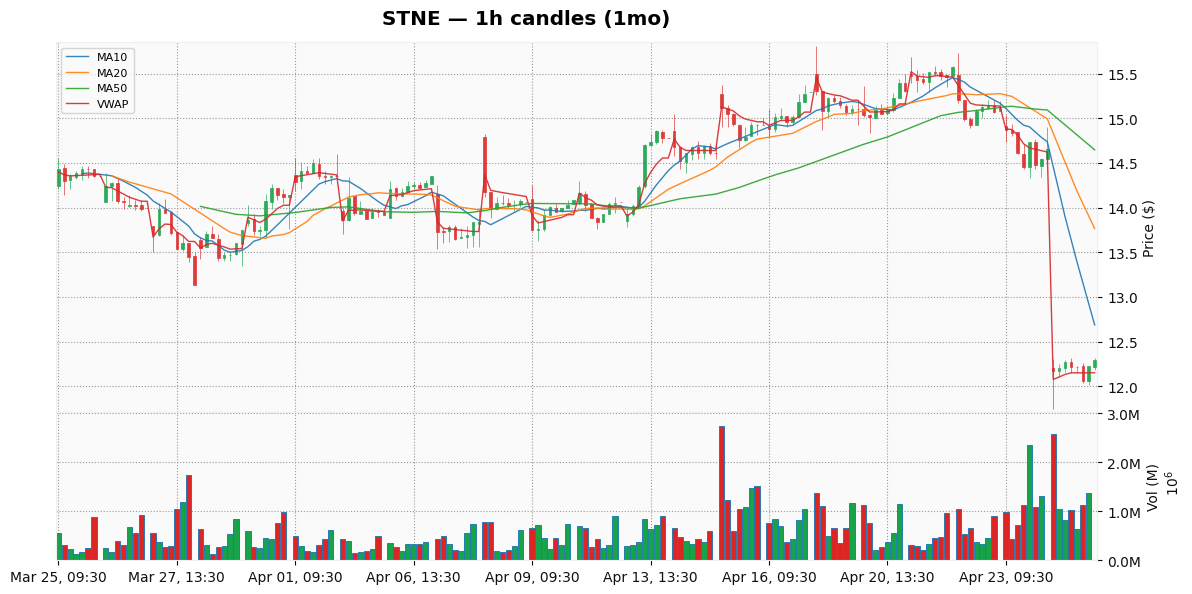

<hr style='margin:1.2rem 0'/>

##### NTLA - Intellia Therapeutics, Inc.

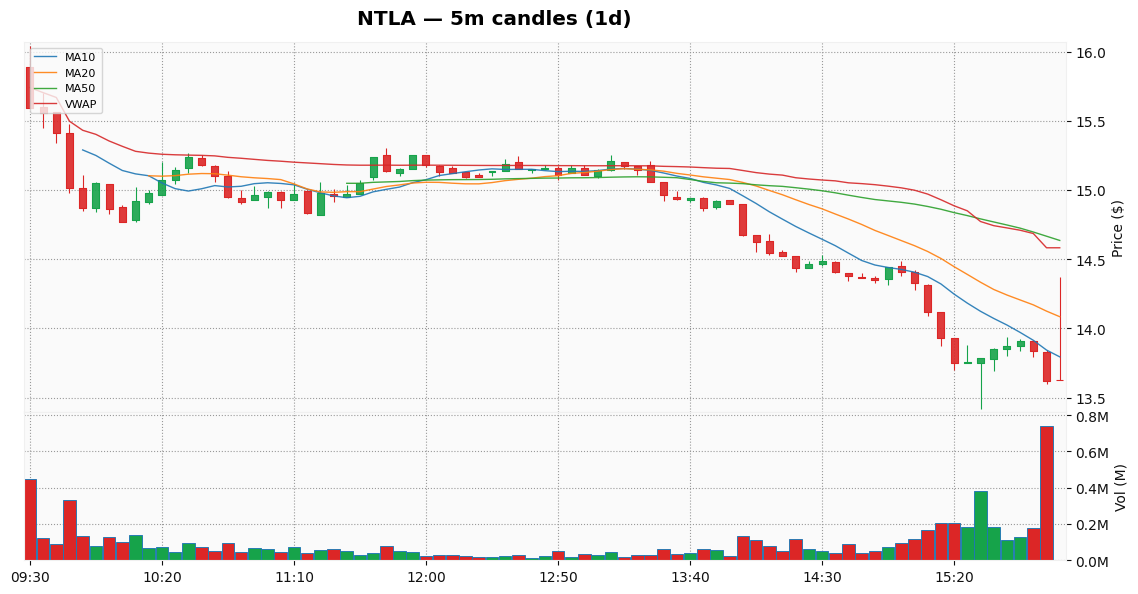

<div style='height:6px'></div>

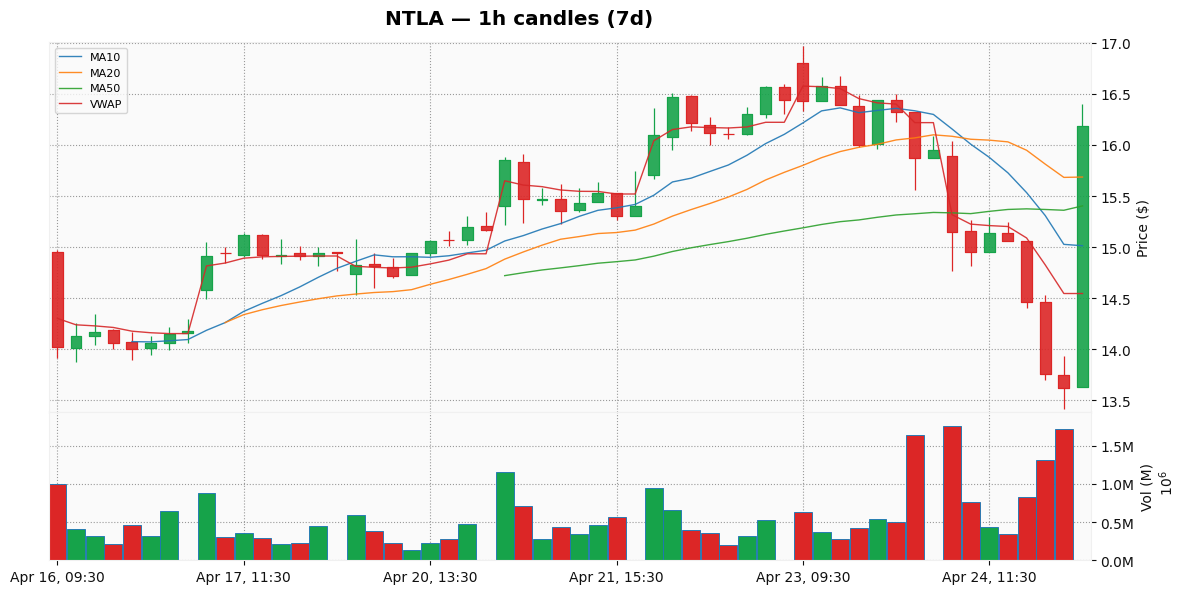

<div style='height:6px'></div>

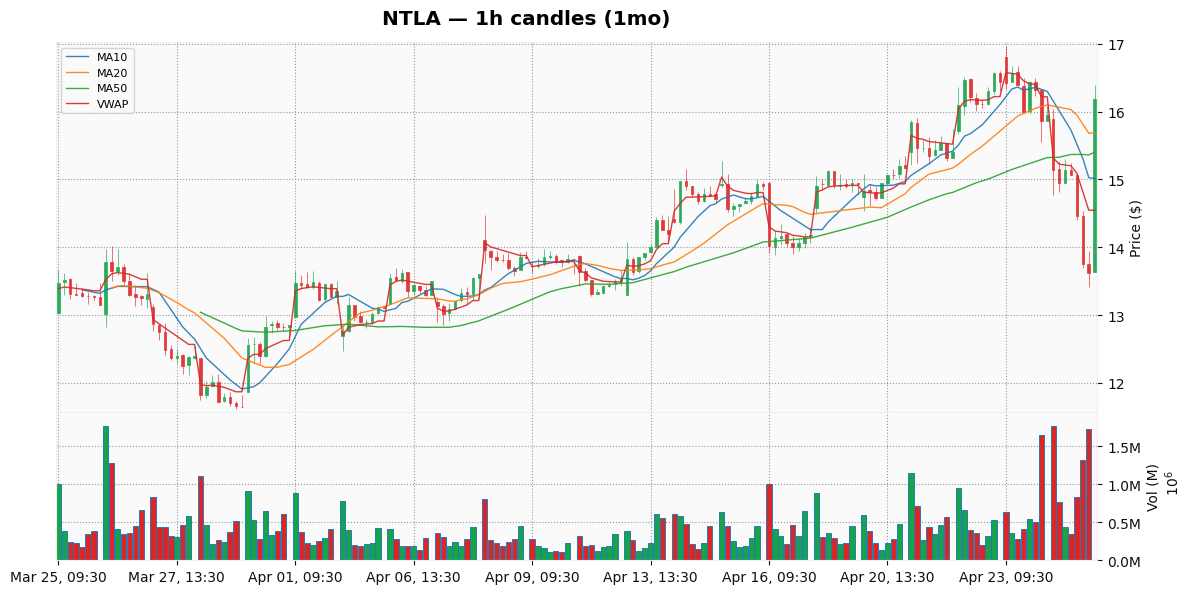

<hr style='margin:1.2rem 0'/>

##### SOXS - Direxion Daily Semiconductor Bear 3X ETF

SOXS: No earnings dates found, symbol may be delisted


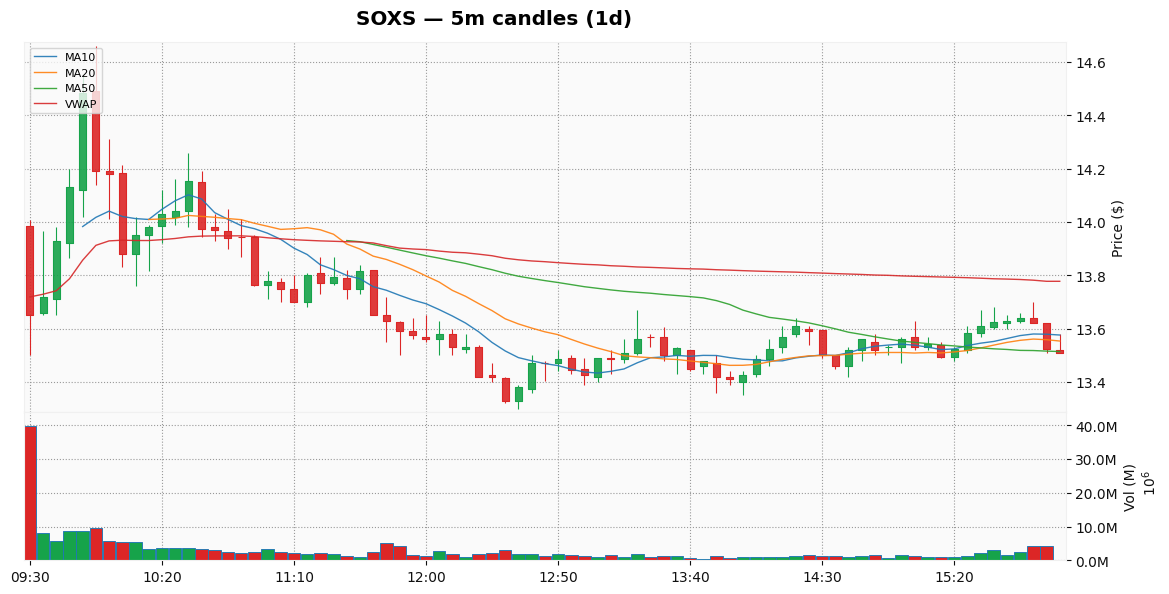

<div style='height:6px'></div>

SOXS: No earnings dates found, symbol may be delisted


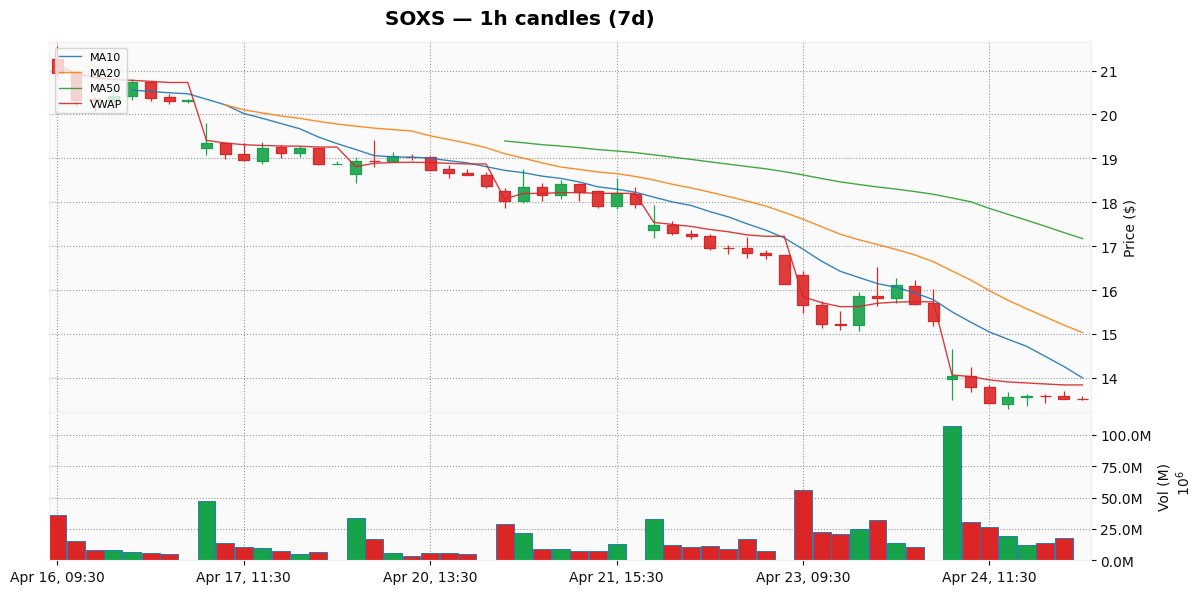

<div style='height:6px'></div>

SOXS: No earnings dates found, symbol may be delisted


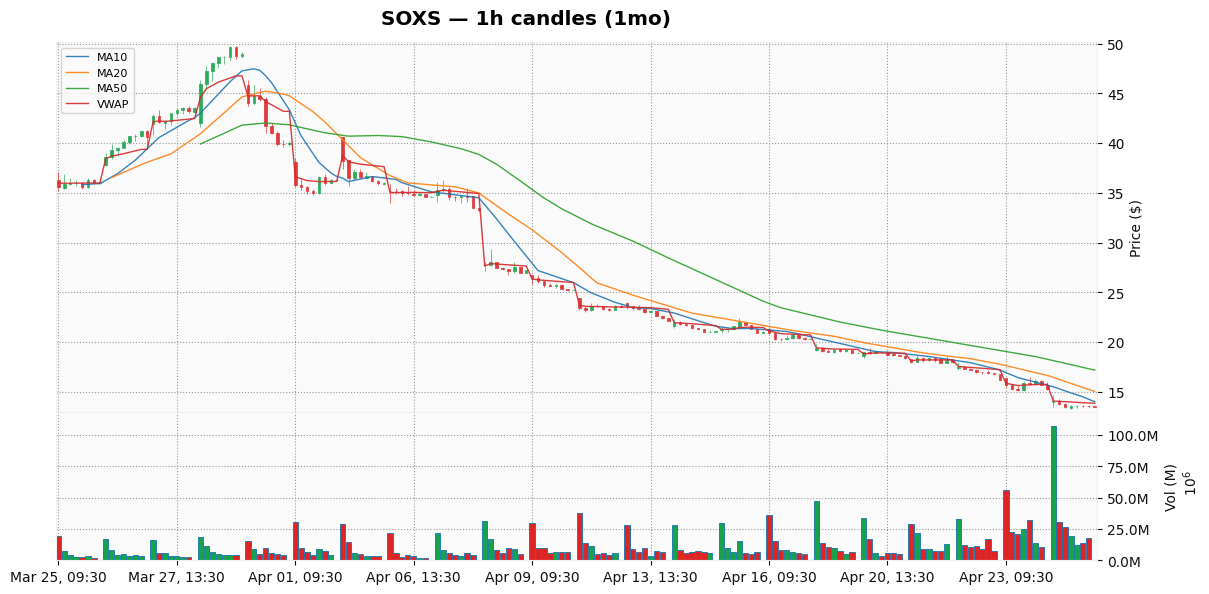

<hr style='margin:1.2rem 0'/>

##### NBIG - Leverage Shares 2x Long NBIS Daily ETF

NBIG: No earnings dates found, symbol may be delisted


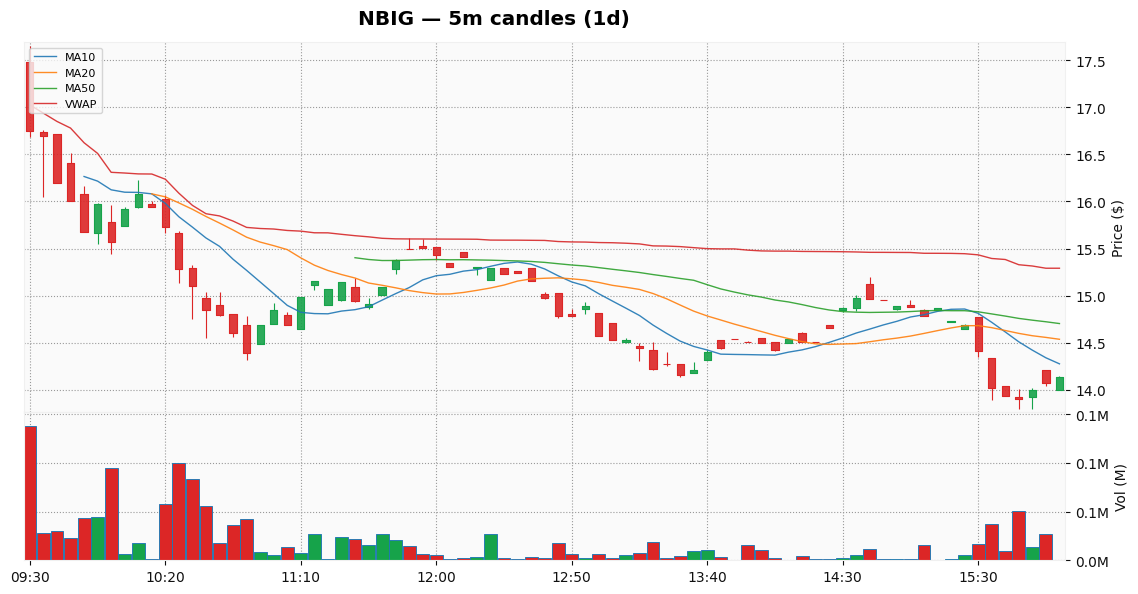

<div style='height:6px'></div>

NBIG: No earnings dates found, symbol may be delisted


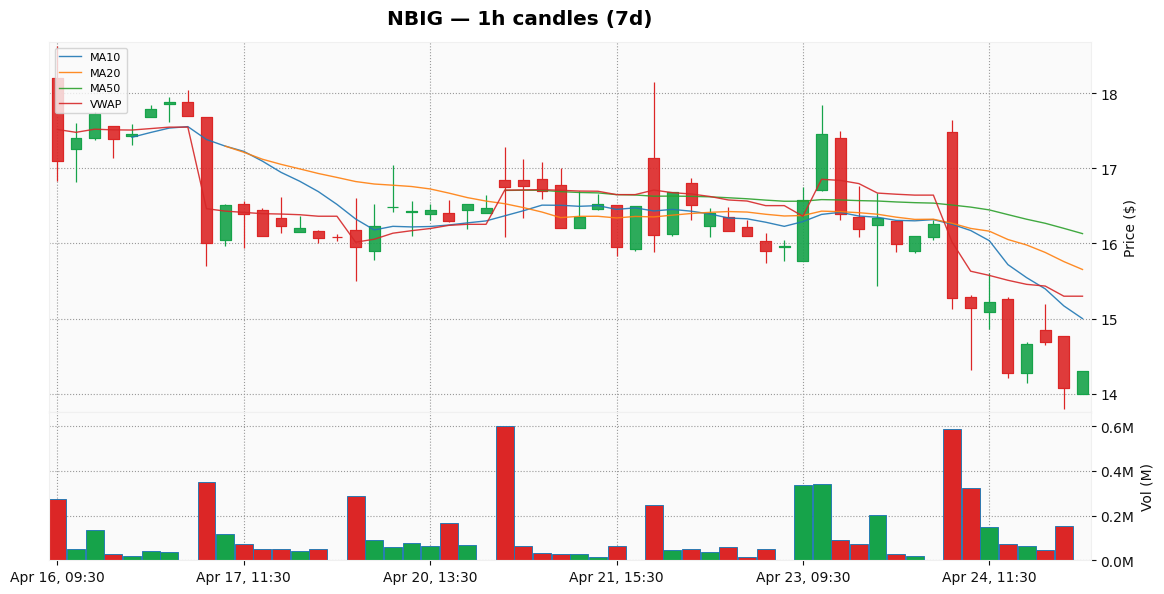

<div style='height:6px'></div>

NBIG: No earnings dates found, symbol may be delisted


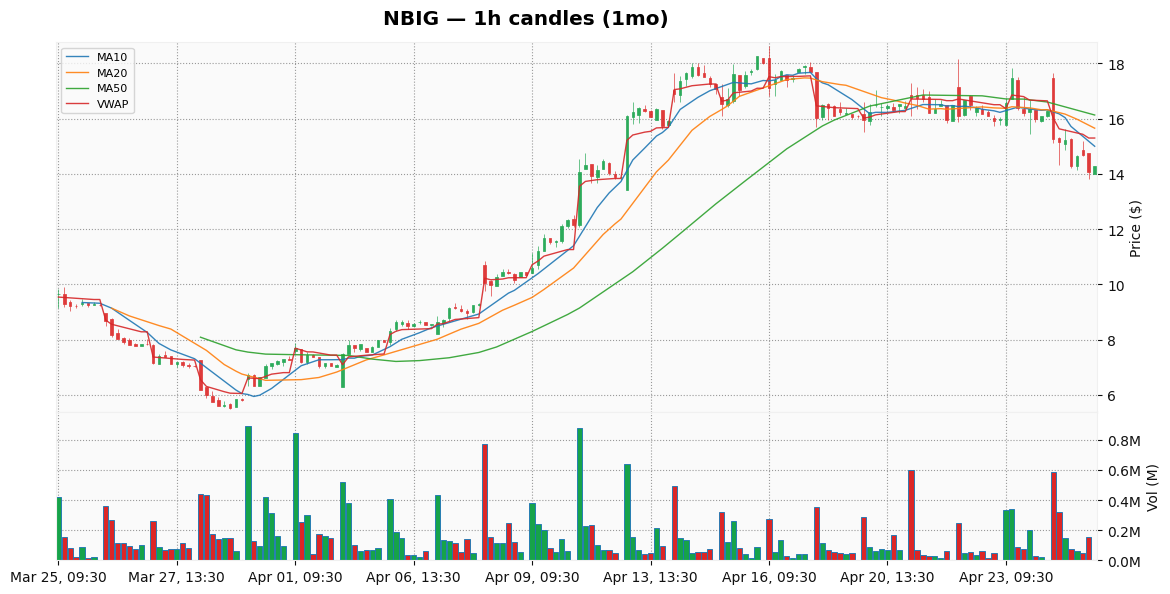

<hr style='margin:1.2rem 0'/>

##### OKLL - Daily Target 2X Long OKLO ETF

OKLL: No earnings dates found, symbol may be delisted


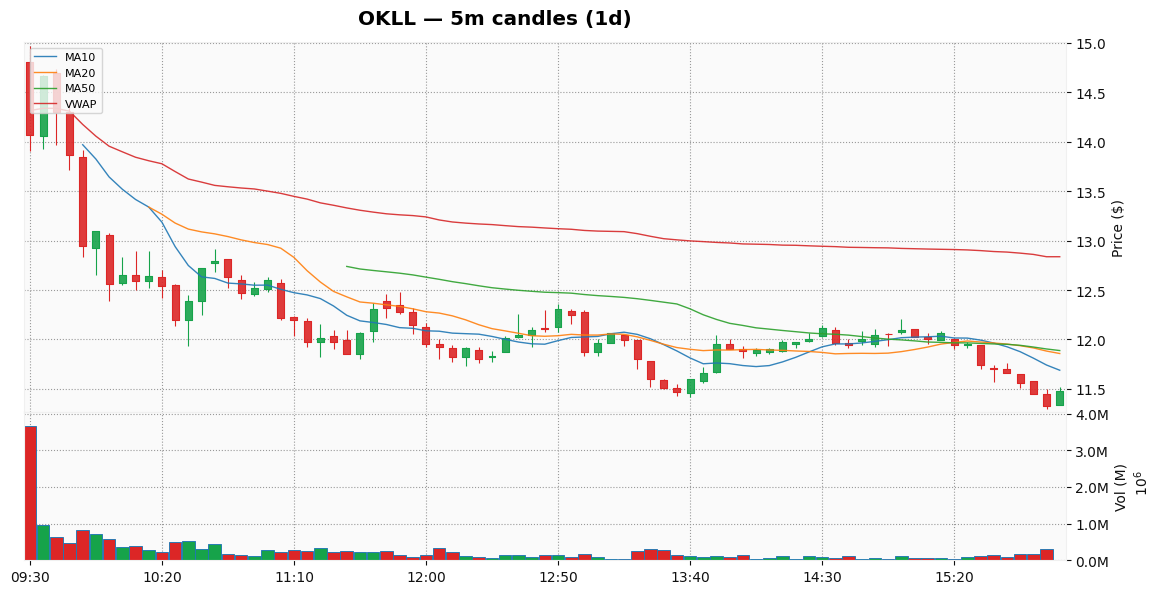

<div style='height:6px'></div>

OKLL: No earnings dates found, symbol may be delisted


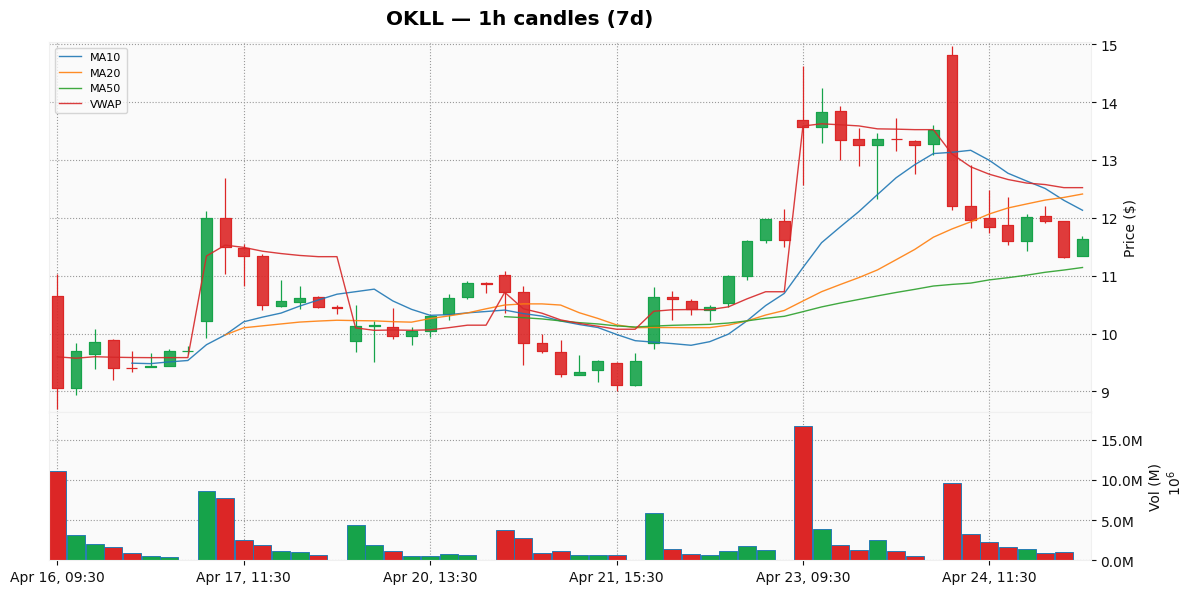

<div style='height:6px'></div>

OKLL: No earnings dates found, symbol may be delisted


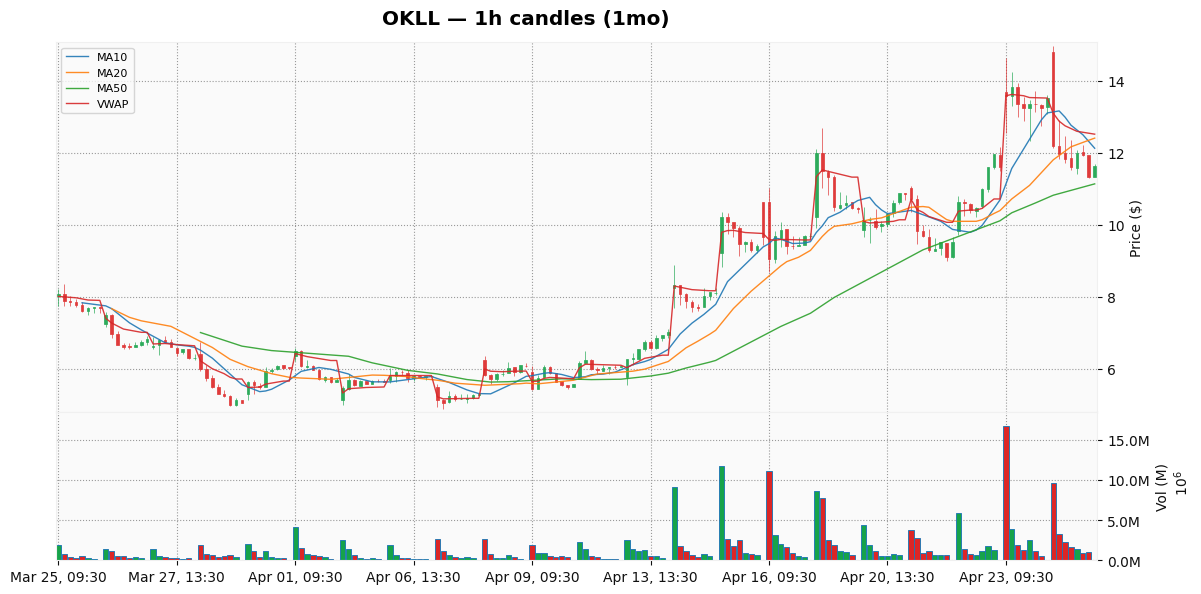

<hr style='margin:1.2rem 0'/>

##### LABT - Lakewood-Amedex Biotherapeutics Inc. Common Stock

LABT: No earnings dates found, symbol may be delisted


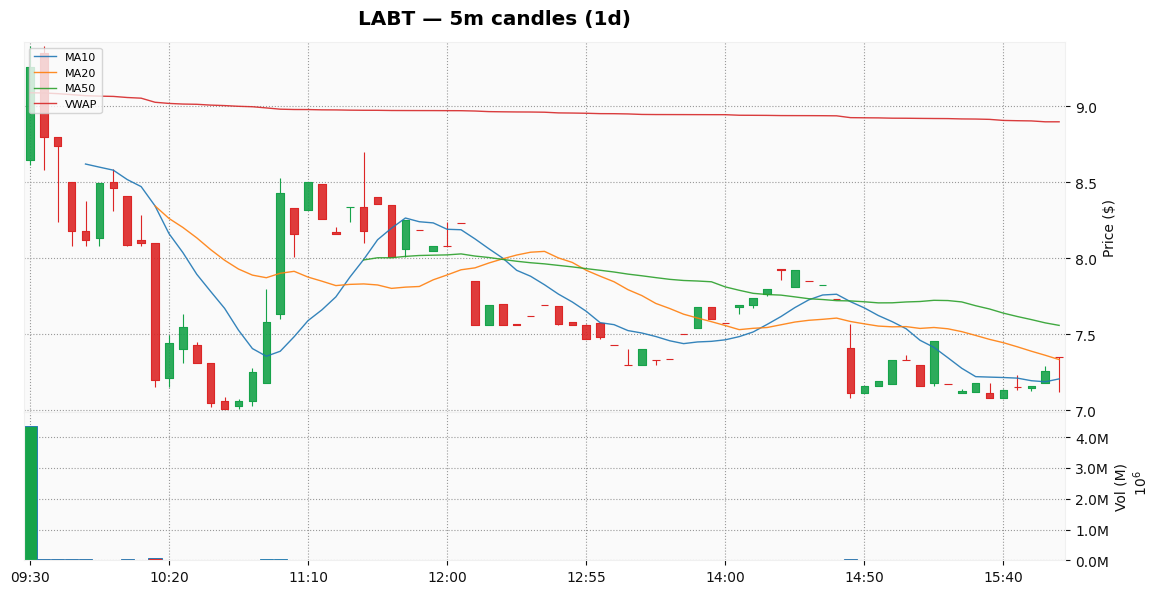

<div style='height:6px'></div>

LABT: No earnings dates found, symbol may be delisted


<div style='color:#b91c1c; font-size:0.9rem;'>⚠️ Skipping LABT (1h, 7d): zero-size array to reduction operation maximum which has no identity</div>

<div style='height:6px'></div>

LABT: No earnings dates found, symbol may be delisted


<div style='color:#b91c1c; font-size:0.9rem;'>⚠️ Skipping LABT (1h, 1mo): zero-size array to reduction operation maximum which has no identity</div>

<hr style='margin:1.2rem 0'/>

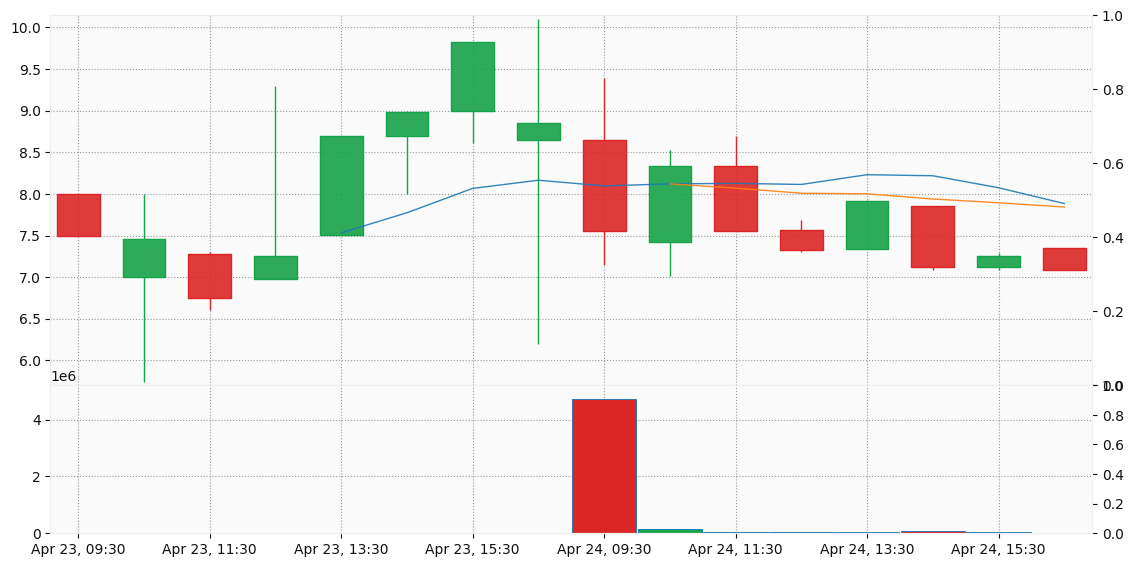

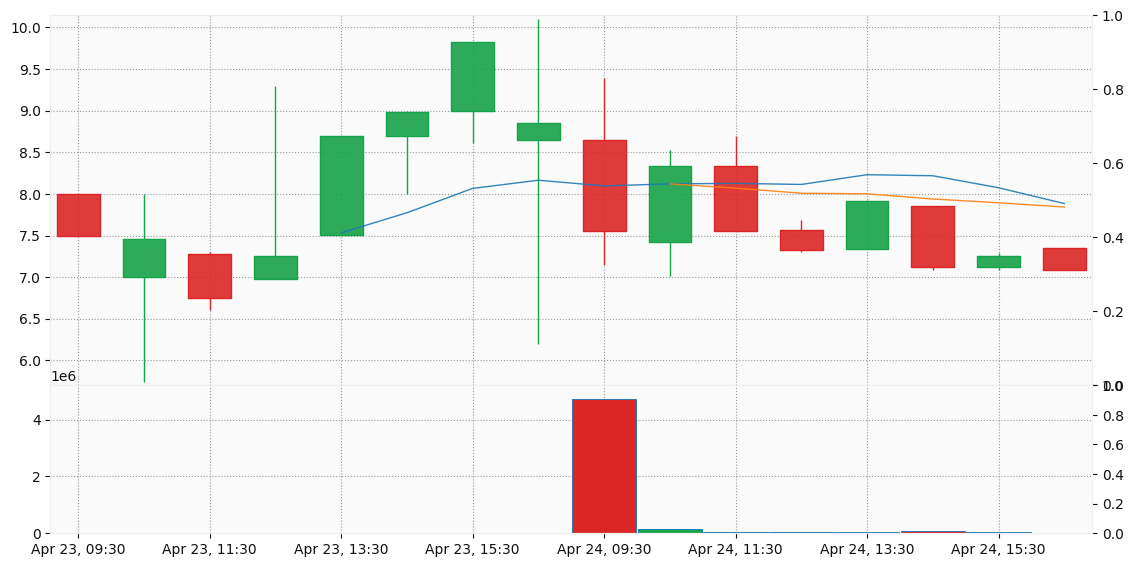

In [15]:
if (True == getPlots):
    plt.rcParams["figure.max_open_warning"] = 0
    plot_three_per_row(dfInterest)

#### Search news related to Tickers of interest

In [16]:
if (True == getNews):
    symbols = sorted({str(s).strip().upper() for s in dfInterest['symbol'].dropna()})
    dfNews = pd.concat([search_news_to_df(s, NEWS_API_KEY, NEWS_PAGE_SIZE) for s in symbols], ignore_index=True).drop_duplicates(subset=['Title']).sort_values('Published At', ascending=False)

    # 1) parse NewsAPI timestamps (ISO8601) → tz-aware
    dfNews["Published At"] = pd.to_datetime(dfNews["Published At"], utc=True, errors="coerce")
    dfNews = dfNews.dropna(subset=["Published At"])  # drop rows with bad/missing dates
    dfNews["Published Local"] = dfNews["Published At"].dt.tz_convert(currentTimezone)

    # 2) keep only items within the last NEWS_DAYS_INTEREST days (inclusive)
    cutoff = pd.Timestamp.now(currentTimezone) - pd.Timedelta(days=NEWS_DAYS_INTEREST)
    recentDf = dfNews.loc[dfNews["Published Local"] >= cutoff]

    # 3) (optional) de-dup within a symbol by Title
    recent = recentDf.drop_duplicates(subset=["Ticker", "Title"])

    # 4) newest first per symbol, then take at most NUM_NEWS each
    dfNewsFinal = (
        recentDf.sort_values(["Ticker", "Published Local"], ascending=[True, False])
            .groupby("Ticker", as_index=False, group_keys=False)
            .head(NUM_NEWS)
            .reset_index(drop=True)
    )

No articles found for ticker ARMG.


No articles found for ticker LABT.
No articles found for ticker NBIG.


No articles found for ticker OKLL.


No articles found for ticker QCML.


No articles found for ticker SKLZ.


In [17]:
if (True == getNews):
    display(HTML(dfNewsFinal[["Ticker", "Company Name", "Title", "Author", "Source", "Published Local"]].to_html(escape=False)))

,Ticker,Company Name,Title,Author,Source,Published Local
0,AKAN,Akanda Corp.,Fracture by Alpaprana,N/A,Fontspace.com,2026-04-25 04:55:59-04:00
1,AKAN,Akanda Corp.,Hicheta by Blankids,N/A,Fontspace.com,2026-04-25 01:52:37-04:00
2,AKAN,Akanda Corp.,Environmental Activist’s Detention Undermines Türkiye’s Role as COP31 Co-host,Human Rights Watch,Human Rights Watch,2026-04-24 14:49:25-04:00
3,AKAN,Akanda Corp.,Azzuri Calcio by Studio TRQ,N/A,Fontspace.com,2026-04-24 06:07:28-04:00
4,AKAN,Akanda Corp.,Hightgraff by Cikareotype Studio,N/A,Fontspace.com,2026-04-24 03:41:18-04:00
5,ATOM,Atomera Incorporated,Latest “quantum computer breaks the math behind Bitcoin” headlines massively exaggerate risk,Gino Matos,CryptoSlate,2026-04-25 05:03:28-04:00
6,ATOM,Atomera Incorporated,Trump Declares Victory in Iran. Reality Disagrees,Mitchell Zimmerman,Juancole.com,2026-04-25 00:06:18-04:00
7,ATOM,Atomera Incorporated,Johnson alum Ted Hurst realizes dream as a 3rd round pick in the NFL Draft,"Dennis Knight, Savannah Morning News",Savannah Morning News,2026-04-24 23:47:08-04:00
8,ATOM,Atomera Incorporated,A look back at the world’s worst nuclear power plant disaster,Kurt Snibbe,OCRegister,2026-04-24 22:01:09-04:00
9,ATOM,Atomera Incorporated,tigrbl-atoms 0.1.12.dev1,jacob@swarmauri.com,Pypi.org,2026-04-24 20:34:59-04:00


### Export Notebook

In [18]:
if (True == exportHtml):
    _ = export_notebook_to_html(
        f"{NOTEBOOK_PATH}",
        f"{HTML_OUT_PATH}",
        hide_code=True,
        remove_tags=["nohtml", "NoReport"]
    )

### Send out Email

In [19]:
if (True == sendEmail):
    tz = ZoneInfo(currentTimezone)
    today_str = datetime.now(tz).date().isoformat()
    timestamp    = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S %Z%z")
    elapsed_time = datetime.now(ZoneInfo(currentTimezone)) - start_ts

    html_body = f"""
    <html>
        <head></head>
        <body>
        <h2>Tickers of Interest for Today: {today_str} </h2>
        <p>Completion time for the playbook execution: {timestamp}</p>
        <p>Notebook Execution took: {elapsed_time} </p>
        <p></p>
        <p></p>
        </body>
    </html>
    """

    sender_email = 'dailyfinancereportjoses@gmail.com'
    email_subject = f"Market Analysis - {today_str}"
    # send_html_email(sender_email, receiver_email, subject, html_body, GMAIL_APP_PASSWORD)
    send_html_email_with_attachment(sender_email= sender_email, receiver_email=TARGET_EMAIL, subject=email_subject, html_path=HTML_OUT_PATH, summary_html = html_body, app_password=GMAIL_APP_PASSWORD)

Attachment size: 6.16 MB (approx 8.44 MB encoded).


Email sent successfully!
